Plot points

In [1]:
import numpy as np
import scipy
from scipy.stats import qmc
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. 星形区域 r_Q(theta, phi)
# ==============================
def rQ(theta, phi):
    return np.sqrt(
        1
        + np.sin(2 * np.sin(phi) * np.cos(theta))**2
        * np.sin(2 * np.sin(phi) * np.sin(theta))**2
        * np.sin(2 * np.cos(phi))**2
    )

# ==============================
# inside 判断
# ==============================
def inside_star(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)

    # 避免除0
    eps = 1e-14
    theta = np.arctan2(y, x)
    phi = np.arccos(np.clip(z / (r + eps), -1, 1))

    rq = rQ(theta, phi)
    return r <= rq


# ==============================
# 主生成函数
# ==============================
def generator_points_3d(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    R_ptch,
):
    # ==============================
    # 2. bounding box
    # ==============================
    N_tmp = 20000
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_tmp)

    theta = 2 * np.pi * pts[:, 0]
    phi = np.arccos(1 - 2 * pts[:, 1])

    r = rQ(theta, phi)

    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)

    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    z_min, z_max = z.min(), z.max()

    # ==============================
    # 3. Patch 网格
    # ==============================
    Nx = N_patch_grid

    Cx = np.linspace(x_min, x_max, Nx)
    Cy = np.linspace(y_min, y_max, Nx)
    Cz = np.linspace(z_min, z_max, Nx)

    Cx, Cy, Cz = np.meshgrid(Cx, Cy, Cz)
    C_all = np.vstack([Cx.ravel(), Cy.ravel(), Cz.ravel()]).T

    R_all = R_ptch * np.ones(len(C_all))

    # ==============================
    # 4. Patch 筛选
    # ==============================
    keep = np.zeros(len(C_all), dtype=bool)

    for i, C in enumerate(C_all):
        sampler = qmc.Halton(d=2, scramble=False)
        s = sampler.random(200)

        th = 2 * np.pi * s[:, 0]
        ph = np.arccos(1 - 2 * s[:, 1])

        xs = C[0] + R_ptch * np.sin(ph) * np.cos(th)
        ys = C[1] + R_ptch * np.sin(ph) * np.sin(th)
        zs = C[2] + R_ptch * np.cos(ph)

        if np.any(inside_star(xs, ys, zs)):
            keep[i] = True

    C_keep = C_all[keep]
    R_keep = R_all[keep]
    # print("Patch 数量:", len(C_keep))
    # ==============================
    # 5. Patch 内点
    # ==============================
    X_inner_list = []
    C_valid = []
    for C in C_keep:
        sampler = qmc.Halton(d=3, scramble=False)
        pts = sampler.random(N_local_per_patch)

        u, v, w = pts[:, 0], pts[:, 1], pts[:, 2]

        theta = 2 * np.pi * u
        phi = np.arccos(1 - 2 * v)
        r = R_ptch * (w ** (1/3))

        x = C[0] + r * np.sin(phi) * np.cos(theta)
        y = C[1] + r * np.sin(phi) * np.sin(theta)
        z = C[2] + r * np.cos(phi)

        mask = inside_star(x, y, z)
        X_inner_patch = np.vstack([x[mask], y[mask], z[mask]]).T
        if X_inner_patch.shape[0] > 0:
            C_valid.append(C)
            X_inner_list.append(np.vstack([x[mask], y[mask], z[mask]]).T)
        else:
            continue
    C_valid = np.array(C_valid)
    X_inner = np.vstack(X_inner_list)
    len_C_valid = len(C_valid)
    print("有效 patch 数量:", len_C_valid)
    print("X_inner 数量:", len(X_inner))

    # ==============================
    # 6. 边界点
    # ==============================
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_boundary)

    theta = 2 * np.pi * pts[:, 0]
    phi = np.arccos(1 - 2 * pts[:, 1])

    r = rQ(theta, phi)

    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)

    X_boundary = np.vstack([x, y, z]).T
    print("X_boundary 数量:", len(X_boundary))
    R_valid = R_ptch * np.ones(len_C_valid)
    return X_inner, X_boundary, C_valid, R_valid

# ==============================
# 2. 可视化函数
# ==============================
def visualize_points(X_inner, X_boundary):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    # ==========================
    # 1. 生成参考边界（仅用于 wireframe）
    # ==========================
    n_theta = 60
    n_phi = 60

    theta = np.linspace(0, 2*np.pi, n_theta)
    phi = np.linspace(0, np.pi, n_phi)

    theta, phi = np.meshgrid(theta, phi)
    r = rQ(theta, phi)
    X = r * np.sin(phi) * np.cos(theta)
    Y = r * np.sin(phi) * np.sin(theta)
    Z = r * np.cos(phi)
    print("Z.shape",Z.shape)
    
    # ==========================
    # 2. wireframe（只做几何参考）
    # ==========================
    ax.plot_wireframe(
        X, Y, Z,
        rstride=2, cstride=2,
        color='black',
        linewidth=0.5,
        alpha=0.8,
        zorder=0.5
    )

    # ==========================
    # 3. Boundary 点（输入）
    # ==========================
    sc_boundary = ax.scatter(
        X_boundary[:, 0].flatten(),
        X_boundary[:, 1].flatten(),
        X_boundary[:, 2].flatten(),
        s=1,
        color='blue',
        depthshade=False,
        zorder=2,
        label='Boundary points'
    )

    # ==========================
    # 4. 内点
    # ==========================
    sc_inner = ax.scatter(
        X_inner[::8, 0].flatten(),
        X_inner[::8, 1].flatten(),
        X_inner[::8, 2].flatten(),
        s=2,
        color='red',
        alpha=0.7,
        depthshade=False,
        zorder=3,
        label='Interior points'
    )

    # ==========================
    # 5. 外观设置（论文风格）
    # ==========================
    ticks = [-1, -0.5, 0, 0.5, 1]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    # ==========================
    # 6. 视角
    # ==========================
    ax.view_init(elev=35, azim=45)
    plt.tight_layout()
    # plt.savefig('./3d_points_distribution.pdf', bbox_inches='tight')
    plt.savefig('./3d_points_distribution.jpg', format='jpg', bbox_inches='tight')
    plt.show()

Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 111
removed patches: 14
patch nX min/mean/max:1 / 139.59 / 497
X_inner: 3101
X_boundary: 1000


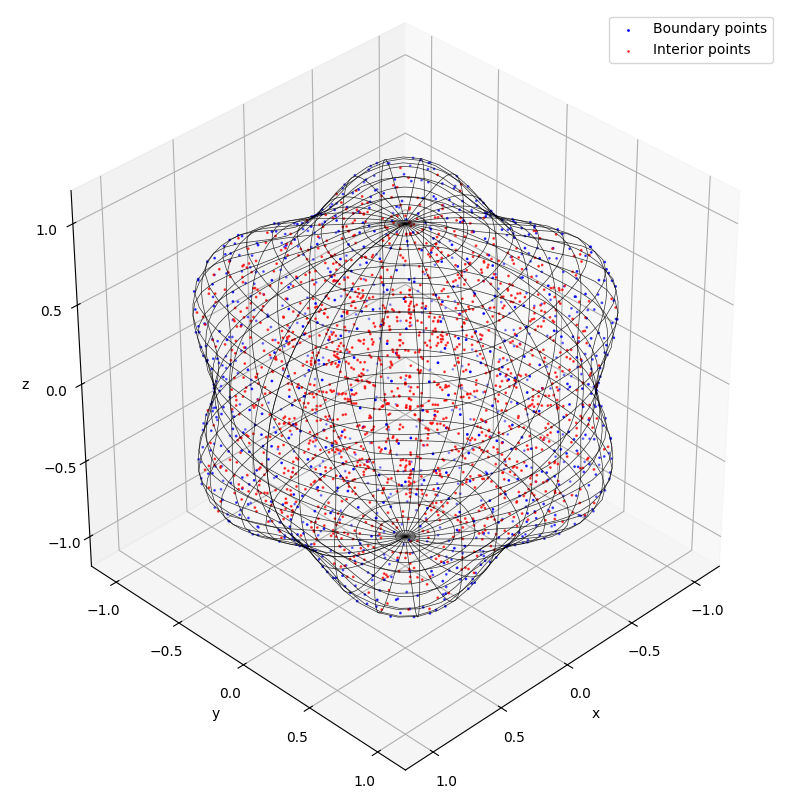

填充间距: 0.1184891034951291


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import qmc
# =========================================================
# 1. star-shaped boundary
# =========================================================
def rQ(theta, phi):
    return np.sqrt(
        1
        + np.sin(2 * np.sin(phi) * np.cos(theta))**2
        * np.sin(2 * np.sin(phi) * np.sin(theta))**2
        * np.sin(2 * np.cos(phi))**2
    )
# =========================================================
# 2. inside test
# =========================================================
def inside_star(x, y, z, eps=1e-12):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arctan2(y, x)
    phi = np.arccos(np.clip(z / (r + eps), -1, 1))
    return r <= rQ(theta, phi)

# =========================================================
# 3. generate boundary points
# =========================================================
def generate_boundary_points(N_boundary=2000):
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_boundary)
    theta = 2 * np.pi * pts[:, 0]
    phi = np.arccos(1 - 2 * pts[:, 1])
    r = rQ(theta, phi)
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    return np.vstack([x, y, z]).T
# =========================================================
# 4. generate patch centers and H
# =========================================================
def generate_centers_auto_H(N_patch_grid, rQ, margin=0.1):
    """
    Returns
    -------
    C    : (N_patch_grid^3, 3)
    H    : scalar, max(Hx, Hy, Hz)
    """
    N_tmp = 20000
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_tmp)
    theta = 2.0 * np.pi * pts[:, 0]
    phi = np.arccos(1.0 - 2.0 * pts[:, 1])
    r = rQ(theta, phi)
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    x_min = x.min() - margin
    x_max = x.max() + margin
    y_min = y.min() - margin
    y_max = y.max() + margin
    z_min = z.min() - margin
    z_max = z.max() + margin
    Hx = (x_max - x_min) / (N_patch_grid - 1)
    Hy = (y_max - y_min) / (N_patch_grid - 1)
    Hz = (z_max - z_min) / (N_patch_grid - 1)
    H = max(Hx, Hy, Hz)
    Cx = np.linspace(x_min, x_max, N_patch_grid)
    Cy = np.linspace(y_min, y_max, N_patch_grid)
    Cz = np.linspace(z_min, z_max, N_patch_grid)
    Xg, Yg, Zg = np.meshgrid(Cx, Cy, Cz, indexing="ij")
    C = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
    return C, H

def compute_R_from_H_delta(H, delta):
    return (1 + delta) * np.sqrt(3) * H / 2

# =========================================================
# 5. generate inner points via patch + filter
# =========================================================
def generate_inner_points(C, R, N_local):
    X_list = []
    for c in C:
        sampler = qmc.Halton(d=3, scramble=False)
        pts = sampler.random(N_local)
        u, v, w = pts[:, 0], pts[:, 1], pts[:, 2]
        theta = 2 * np.pi * u
        phi = np.arccos(1 - 2 * v)
        r = R * (w ** (1/3))
        x = c[0] + r * np.sin(phi) * np.cos(theta)
        y = c[1] + r * np.sin(phi) * np.sin(theta)
        z = c[2] + r * np.cos(phi)
        X_list.append(np.vstack([x, y, z]).T)
    X_raw = np.vstack(X_list)
    # ======= 关键：投影回 star domain =======
    mask = inside_star(
        X_raw[:, 0],
        X_raw[:, 1],
        X_raw[:, 2]
    )
    X_inner = X_raw[mask]
    return X_inner

def remove_empty_patches_by_Xinner(C_raw, R, X_inner):
    """
    Remove patches that contain no interior points.
    Parameters
    ----------
    C_raw : (Np, 3)
        Patch centers
    R : scalar or (Np,)
        Patch radius
    X_inner : (N, 3)
        Interior points
    Returns
    -------
    C_new : (Np_new, 3)
    R_new : (Np_new,)
    keep  : (Np,) bool mask
    nX    : (Np,) number of points inside each patch
    """
    C_raw = np.asarray(C_raw)
    X_inner = np.asarray(X_inner)
    if np.isscalar(R):
        R_vec = np.full(C_raw.shape[0], R)
    else:
        R_vec = np.asarray(R)
    tree_X = cKDTree(X_inner)
    keep = np.zeros(C_raw.shape[0], dtype=bool)
    nX = np.zeros(C_raw.shape[0], dtype=int)
    for j, c in enumerate(C_raw):
        idx = tree_X.query_ball_point(c, R_vec[j])
        nX[j] = len(idx)
        if nX[j] > 0:
            keep[j] = True
    C_new = C_raw[keep]
    R_new = R_vec[keep]
    print(f"original patches: {C_raw.shape[0]}")
    print(f"kept patches: {C_new.shape[0]}")
    print(f"removed patches: {C_raw.shape[0] - C_new.shape[0]}")
    if np.any(keep):
        print("patch nX min/mean/max:" 
              f"{nX[keep].min()} / {nX[keep].mean():.2f} / {nX[keep].max()}")
    else:
        print("No patches kept!")
    return C_new, R_new, keep, nX
# =========================================================
# 6. 可视化函数
# =========================================================
def visualize_points(X_inner, X_boundary):

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    # ==========================
    # 1. 生成参考边界（仅用于 wireframe）
    # ==========================
    n_theta = 60
    n_phi = 60
    theta = np.linspace(0, 2*np.pi, n_theta)
    phi = np.linspace(0, np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi)
    r = rQ(theta, phi)
    X = r * np.sin(phi) * np.cos(theta)
    Y = r * np.sin(phi) * np.sin(theta)
    Z = r * np.cos(phi)
    ax.plot_wireframe(
        X, Y, Z,
        rstride=2, cstride=2,
        color='black',
        linewidth=0.5,
        alpha=0.8,
        zorder=0.5
    )
    # ==========================
    # 2. Boundary 点
    # ==========================
    ax.scatter(
        X_boundary[:, 0],
        X_boundary[:, 1],
        X_boundary[:, 2],
        s=1,
        color='blue',
        depthshade=True,
        zorder=2,
        label='Boundary points'
    )
    # ==========================
    # 3. 内点
    # ==========================
    ax.scatter(
        X_inner[::2, 0],
        X_inner[::2, 1],
        X_inner[::2, 2],
        s=1,
        color='red',
        alpha=0.7,
        depthshade=True,
        zorder=3,
        label='Interior points'
    )
    # ==========================
    # 4. 视觉设置
    # ==========================
    ticks = [-1, -0.5, 0, 0.5, 1]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.view_init(elev=35, azim=45)
    plt.tight_layout()
    plt.show()

# =========================================================
# 7. main
# =========================================================
def generator_points_3d_overlap(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap,
    visu
):

    X_boundary = generate_boundary_points(N_boundary)
    X_boundary = unique_points_by_tol(X_boundary, tol=1e-10)
    # =====================================================
    # 1. raw centers
    # =====================================================
    C_raw, H = generate_centers_auto_H(N_patch_grid, rQ, margin=0.1)
    h = H/(N_local_per_patch)**(1/3)
    info = {
        "H": H ,
        "h": h
            }

    print("Generator's C:", len(C_raw))
    # =====================================================
    # 2. compute R from overlap in 3D
    # =====================================================
    R = compute_R_from_H_delta(H, overlap) # scalar
    print("Generator's R =", R)
    # =====================================================
    # 3. inner points and filter C
    # =====================================================
    X_inner = generate_inner_points(C_raw, R, N_local_per_patch)
    X_inner = unique_points_by_tol(X_inner, tol=1e-10)
    C,R,_,_=remove_empty_patches_by_Xinner(C_raw, R, X_inner)
    print("X_inner:", len(X_inner))
    print("X_boundary:", len(X_boundary))
    # =====================================================
    # 5. visualization
    # =====================================================
    if visu:
        visualize_points(X_inner, X_boundary)

    return X_inner, X_boundary, C, R, info

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))


def unique_points_by_tol(X, tol=1e-10):
    X = np.asarray(X)
    Xq = np.round(X / tol).astype(np.int64)
    _, idx = np.unique(Xq, axis=0, return_index=True)
    idx = np.sort(idx)
    return X[idx]

N_patch_grid = 5
N_local_per_patch = 100
N_boundary = 1000
overlap = 0.2
visu = True
X_inner, X_boundary, C, R, info = generator_points_3d_overlap(N_patch_grid,N_local_per_patch,N_boundary,overlap,visu)

# dists = np.linalg.norm(X_inner[:, None, :] - X_inner[None, :, :], axis=-1)
# h = fill_distance(X_inner)
print("填充间距:", info['h'])


In [3]:
import numpy as np
from scipy.spatial import cKDTree
from scipy.stats import qmc
### 过采样率 1.5  |Y|/|X| = 1.5 

# =========================================================
# 0. 你已有的 rQ / inside_star / boundary sampler
# =========================================================
def rQ(theta, phi):
    return np.sqrt(
        1
        + np.sin(2 * np.sin(phi) * np.cos(theta))**2
        * np.sin(2 * np.sin(phi) * np.sin(theta))**2
        * np.sin(2 * np.cos(phi))**2
    )

def inside_star(x, y, z, eps=1e-12):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arctan2(y, x)
    phi = np.arccos(np.clip(z / (r + eps), -1.0, 1.0))
    return r <= rQ(theta, phi)


def generate_boundary_points_uniform(N_boundary=2000):
    i = np.arange(N_boundary)
    golden_ratio = (1.0 + np.sqrt(5.0)) / 2.0

    theta = 2.0 * np.pi * i / golden_ratio
    z_sphere = 1.0 - 2.0 * (i + 0.5) / N_boundary
    phi = np.arccos(np.clip(z_sphere, -1.0, 1.0))

    r = rQ(theta, phi)

    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)

    return np.vstack([x, y, z]).T


# =========================================================
# 1. 去重
# =========================================================

def unique_points_by_tol(X, tol=1e-10):
    X = np.asarray(X, dtype=np.float64)
    if X.shape[0] == 0:
        return X

    Xq = np.round(X / tol).astype(np.int64)
    _, idx = np.unique(Xq, axis=0, return_index=True)
    idx = np.sort(idx)

    return X[idx]


# =========================================================
# 2. 估计 domain bounding box
# =========================================================

def estimate_star_bbox(N_tmp=50000, margin=0.05):
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_tmp)

    theta = 2.0 * np.pi * pts[:, 0]
    phi = np.arccos(1.0 - 2.0 * pts[:, 1])

    r = rQ(theta, phi)

    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)

    return {
        "xmin": x.min() - margin,
        "xmax": x.max() + margin,
        "ymin": y.min() - margin,
        "ymax": y.max() + margin,
        "zmin": z.min() - margin,
        "zmax": z.max() + margin,
    }


# =========================================================
# 3. 生成 interior extra test points：Halton + rejection
# =========================================================

def generate_inner_halton_points(
    N_inner,
    bbox=None,
    seed=1234,
    scramble=True,
    batch_size=20000,
):
    N_inner = int(N_inner)

    if N_inner <= 0:
        return np.zeros((0, 3), dtype=np.float64)

    if bbox is None:
        bbox = estimate_star_bbox()

    xmin, xmax = bbox["xmin"], bbox["xmax"]
    ymin, ymax = bbox["ymin"], bbox["ymax"]
    zmin, zmax = bbox["zmin"], bbox["zmax"]

    sampler = qmc.Halton(d=3, scramble=scramble, seed=seed)

    pts_keep = []
    need = N_inner

    while need > 0:
        pts = sampler.random(batch_size)

        x = xmin + (xmax - xmin) * pts[:, 0]
        y = ymin + (ymax - ymin) * pts[:, 1]
        z = zmin + (zmax - zmin) * pts[:, 2]

        mask = inside_star(x, y, z)
        P = np.vstack([x[mask], y[mask], z[mask]]).T

        if P.shape[0] == 0:
            continue

        take = min(need, P.shape[0])
        pts_keep.append(P[:take])
        need -= take

    return np.vstack(pts_keep)


# =========================================================
# 4. 在一个 patch 内补 interior test points
# =========================================================

def sample_points_in_patch_inside_domain(
    c,
    R,
    n_need,
    seed=1234,
    batch_size=None,
):
    n_need = int(n_need)

    if n_need <= 0:
        return np.zeros((0, 3), dtype=np.float64)

    rng = np.random.default_rng(seed)

    pts_keep = []
    need = n_need

    if batch_size is None:
        batch_size = max(2000, 50 * n_need)

    while need > 0:
        u = rng.random(batch_size)
        v = rng.random(batch_size)
        w = rng.random(batch_size)

        theta = 2.0 * np.pi * u
        phi = np.arccos(1.0 - 2.0 * v)
        rr = R * (w ** (1.0 / 3.0))

        x = c[0] + rr * np.sin(phi) * np.cos(theta)
        y = c[1] + rr * np.sin(phi) * np.sin(theta)
        z = c[2] + rr * np.cos(phi)

        mask = inside_star(x, y, z)
        P = np.vstack([x[mask], y[mask], z[mask]]).T

        if P.shape[0] == 0:
            continue

        take = min(need, P.shape[0])
        pts_keep.append(P[:take])
        need -= take

    return np.vstack(pts_keep)


# =========================================================
# 5. 统计每个 patch 的 beta_j = |Y_j| / |X_j|
# =========================================================

def patch_oversampling_stats(C, R, X, Yin, Yb):
    C = np.asarray(C, dtype=np.float64)
    R = np.asarray(R, dtype=np.float64)

    X = np.asarray(X, dtype=np.float64)
    Y = np.vstack([Yin, Yb])

    tree_X = cKDTree(X)
    tree_Y = cKDTree(Y)

    Np = C.shape[0]

    nX = np.zeros(Np, dtype=int)
    nY = np.zeros(Np, dtype=int)
    beta = np.full(Np, np.nan, dtype=np.float64)

    bad = []

    for j in range(Np):
        idx_X = tree_X.query_ball_point(C[j], R[j])
        idx_Y = tree_Y.query_ball_point(C[j], R[j])

        nX[j] = len(idx_X)
        nY[j] = len(idx_Y)

        if nX[j] > 0:
            beta[j] = nY[j] / nX[j]

            if nY[j] < nX[j]:
                bad.append((j, nX[j], nY[j], beta[j]))

    active = nX > 0

    return nX, nY, beta, active, bad


def print_oversampling_stats(C, R, X, Yin, Yb, beta_target=1.5):
    nX, nY, beta, active, bad = patch_oversampling_stats(C, R, X, Yin, Yb)

    Y = np.vstack([Yin, Yb])
    beta_global = Y.shape[0] / X.shape[0]

    print("========== oversampling stats ==========")
    print("|X| =", X.shape[0])
    print("|Y| =", Y.shape[0])
    print("global beta |Y|/|X| =", beta_global)
    print("target beta =", beta_target)
    print("----------------------------------------")
    print("patch nX min/mean/max:",
          nX[active].min(),
          nX[active].mean(),
          nX[active].max())
    print("patch nY min/mean/max:",
          nY[active].min(),
          nY[active].mean(),
          nY[active].max())
    print("patch beta_j min/mean/max:",
          np.nanmin(beta[active]),
          np.nanmean(beta[active]),
          np.nanmax(beta[active]))
    print("bad patches beta_j < 1:", len(bad))
    print("patches beta_j < target:",
          np.sum(beta[active] < beta_target))

    if len(bad) > 0:
        bad_sorted = sorted(bad, key=lambda t: t[3])
        print("worst bad patches:")
        for item in bad_sorted[:10]:
            print("patch, nX, nY, beta_j =", item)

    return {
        "nX": nX,
        "nY": nY,
        "beta": beta,
        "active": active,
        "bad": bad,
        "beta_global": beta_global,
    }


# =========================================================
# 6. patch-wise 补 Yin，使 beta_j 达到 beta_min_patch
# =========================================================

def add_Yin_until_patch_beta(
    C,
    R,
    X,
    Yin,
    Yb,
    beta_min_patch=1.5,
    max_passes=3,
    seed=1234,
    unique_tol=1e-10,
):
    C = np.asarray(C, dtype=np.float64)
    R = np.asarray(R, dtype=np.float64)

    X = np.asarray(X, dtype=np.float64)
    Yin_new = np.asarray(Yin, dtype=np.float64).copy()
    Yb = np.asarray(Yb, dtype=np.float64)

    tree_X = cKDTree(X)

    for pass_id in range(max_passes):
        Y = np.vstack([Yin_new, Yb])
        tree_Y = cKDTree(Y)

        add_list = []
        bad_count = 0
        total_add = 0

        for j in range(C.shape[0]):
            idx_X = tree_X.query_ball_point(C[j], R[j])
            idx_Y = tree_Y.query_ball_point(C[j], R[j])

            nX = len(idx_X)
            nY = len(idx_Y)

            if nX == 0:
                continue

            target = int(np.ceil(beta_min_patch * nX))

            if nY < target:
                bad_count += 1
                n_add = target - nY
                total_add += n_add

                P_add = sample_points_in_patch_inside_domain(
                    C[j],
                    R[j],
                    n_add,
                    seed=seed + 10007 * j + 1000003 * pass_id,
                )

                add_list.append(P_add)

        print(
            f"pass {pass_id}: patches below beta_min = {bad_count}, "
            f"new Yin points planned = {total_add}"
        )

        if len(add_list) == 0:
            break

        Yin_new = np.vstack([Yin_new] + add_list)
        Yin_new = unique_points_by_tol(Yin_new, tol=unique_tol)

    return Yin_new


# =========================================================
# 7. 主函数：基于你的 X_inner, X_boundary, C, R 生成 Yin, Yb
# =========================================================

def generate_Y_for_oversampling_from_your_points(
    X_inner,
    X_boundary,
    C,
    R,
    beta_global_target=1.5,
    beta_boundary=1.5,
    beta_min_patch=1.2,
    enforce_patch=True,
    seed=1234,
    unique_tol=1e-10,
):
    """
    基于你的不规则 X_inner / X_boundary / C / R 生成 Yin, Yb.

    参数说明
    ----------
    beta_global_target:
        全局 test/source 比例，默认 1.5.
        这里主要控制 interior extra 点数量。
    beta_boundary:
        边界 test/source 比例，默认 1.5.
    beta_min_patch:
        每个 active patch 的最低 beta_j 要求。
        建议先 1.2，稳定后可用 1.5.
    enforce_patch:
        是否按 patch 补 interior test points.
    """
    X_inner = unique_points_by_tol(X_inner, tol=unique_tol)
    X_boundary = unique_points_by_tol(X_boundary, tol=unique_tol)
    X = np.vstack([X_inner, X_boundary])
    X = unique_points_by_tol(X, tol=unique_tol)
    N_X_inner = X_inner.shape[0]
    N_X_boundary = X_boundary.shape[0]
    N_X = X.shape[0]
    # -----------------------------------------------------
    # 1. 边界 Yb
    # -----------------------------------------------------
    N_Yb_target = int(np.ceil(beta_boundary * N_X_boundary))
    N_Yb_extra = max(N_Yb_target - N_X_boundary, 0)
    Yb_extra = generate_boundary_points_uniform(N_Yb_extra)
    Yb = np.vstack([X_boundary, Yb_extra])
    Yb = unique_points_by_tol(Yb, tol=unique_tol)

    # -----------------------------------------------------
    # 2. interior Yin
    # 目标总 Y 数量约为 beta_global_target * |X|
    # -----------------------------------------------------
    N_Y_total_target = int(np.ceil(beta_global_target * N_X))

    # 已经有 Yb 和 X_inner，剩下由 Yin_extra 补
    N_Yin_extra = N_Y_total_target - Yb.shape[0] - N_X_inner
    N_Yin_extra = max(N_Yin_extra, 0)

    bbox = estimate_star_bbox(margin=0.05)

    Yin_extra = generate_inner_halton_points(
        N_Yin_extra,
        bbox=bbox,
        seed=seed,
        scramble=True,
    )

    Yin = np.vstack([X_inner, Yin_extra])
    Yin = unique_points_by_tol(Yin, tol=unique_tol)

    # -----------------------------------------------------
    # 3. patch-wise 补点
    # -----------------------------------------------------
    if enforce_patch:
        Yin = add_Yin_until_patch_beta(
            C=C,
            R=R,
            X=X,
            Yin=Yin,
            Yb=Yb,
            beta_min_patch=beta_min_patch,
            max_passes=3,
            seed=seed,
            unique_tol=unique_tol,
        )

    # -----------------------------------------------------
    # 4. 打印统计
    # -----------------------------------------------------
    stats = print_oversampling_stats(
        C=C,
        R=R,
        X=X,
        Yin=Yin,
        Yb=Yb,
        beta_target=beta_min_patch,
    )

    info = {
        "X": X,
        "Yin": Yin,
        "Yb": Yb,
        "N_X_inner": N_X_inner,
        "N_X_boundary": N_X_boundary,
        "N_X_total": N_X,
        "N_Yin": Yin.shape[0],
        "N_Yb": Yb.shape[0],
        "N_Y_total": Yin.shape[0] + Yb.shape[0],
        "beta_global": (Yin.shape[0] + Yb.shape[0]) / N_X,
        "beta_boundary_actual": Yb.shape[0] / max(N_X_boundary, 1),
        "stats": stats,
    }

    return X, Yin, Yb, info


X, Yin, Yb, info = generate_Y_for_oversampling_from_your_points(X_inner,
    X_boundary,
    C,
    R,
    # beta_global_target=1.5,
    # beta_boundary=1.5,
    # beta_min_patch=1.2,
    # enforce_patch=True,
    # seed=1234,
    # unique_tol=1e-10,
)

pass 0: patches below beta_min = 0, new Yin points planned = 0
========== oversampling stats ==========
|X| = 4101
|Y| = 6152
global beta |Y|/|X| = 1.5001219214825652
target beta = 1.2
----------------------------------------
patch nX min/mean/max: 10 183.05405405405406 524
patch nY min/mean/max: 14 270.84684684684686 766
patch beta_j min/mean/max: 1.368421052631579 1.4872448496179693 1.7692307692307692
bad patches beta_j < 1: 0
patches beta_j < target: 0


In [4]:
# def generate_boundary_points_uniform(N_boundary=2000):
#     i = np.arange(N_boundary)
#     # Fibonacci sphere directions
#     golden_ratio = (1.0 + np.sqrt(5.0)) / 2.0
#     theta = 2.0 * np.pi * i / golden_ratio
#     z_sphere = 1.0 - 2.0 * (i + 0.5) / N_boundary
#     phi = np.arccos(np.clip(z_sphere, -1.0, 1.0))
#     # Star-shaped radius
#     r = rQ(theta, phi)
#     x = r * np.sin(phi) * np.cos(theta)
#     y = r * np.sin(phi) * np.sin(theta)
#     z = r * np.cos(phi)
#     X_boundary = np.vstack([x, y, z]).T
#     return X_boundary

# def generate_inner_grid_points(h, margin=0.05):
#     # -----------------------------------------------------
#     # 1. Estimate bounding box from boundary samples
#     # -----------------------------------------------------
#     N_tmp = 50000
#     sampler = qmc.Halton(d=2, scramble=False)
#     pts = sampler.random(N_tmp)
#     theta = 2.0 * np.pi * pts[:, 0]
#     phi = np.arccos(1.0 - 2.0 * pts[:, 1])
#     r = rQ(theta, phi)
#     xb = r * np.sin(phi) * np.cos(theta)
#     yb = r * np.sin(phi) * np.sin(theta)
#     zb = r * np.cos(phi)
#     x_min, x_max = xb.min() - margin, xb.max() + margin
#     y_min, y_max = yb.min() - margin, yb.max() + margin
#     z_min, z_max = zb.min() - margin, zb.max() + margin
#     # -----------------------------------------------------
#     # 2. Generate equispaced Cartesian grid
#     # -----------------------------------------------------
#     x = np.arange(x_min, x_max + 0.5 * h, h)
#     y = np.arange(y_min, y_max + 0.5 * h, h)
#     z = np.arange(z_min, z_max + 0.5 * h, h)
#     Xg, Yg, Zg = np.meshgrid(x, y, z, indexing="ij")
#     X_raw = np.vstack([
#         Xg.ravel(),
#         Yg.ravel(),
#         Zg.ravel()
#     ]).T
#     # -----------------------------------------------------
#     # 3. Keep only points inside the star-shaped domain
#     # -----------------------------------------------------
#     mask = inside_star(
#         X_raw[:, 0],
#         X_raw[:, 1],
#         X_raw[:, 2]
#     )
#     X_inner = X_raw[mask]
#     info = {
#         "h": h,
#         "x_range": (x_min, x_max),
#         "y_range": (y_min, y_max),
#         "z_range": (z_min, z_max),
#         "Nx": len(x),
#         "Ny": len(y),
#         "Nz": len(z),
#         "N_raw": X_raw.shape[0],
#         "N_inner": X_inner.shape[0],
#     }
#     return X_inner, info

# def generator_points_3d_grid(
#     h,
#     N_boundary,
#     visu=True
# ):
#     # -----------------------------------------------------
#     # 1. Boundary points
#     # -----------------------------------------------------
#     X_boundary = generate_boundary_points_uniform(N_boundary)
#     # -----------------------------------------------------
#     # 2. Equispaced interior points
#     # -----------------------------------------------------
#     X_inner, grid_info = generate_inner_grid_points(h)
#     info = {
#         "grid_info": grid_info,
#     }

#     print("Interior grid points:", len(X_inner))
#     print("Boundary points:", len(X_boundary))
#     print("Grid spacing h:", h)


#     if visu:
#         visualize_points(X_inner, X_boundary)

#     return X_inner, X_boundary, info


In [5]:
# h = 0.1
# N_patch_grid = 5
# N_boundary = 3000
# overlap = 0.2
# visu = True

# X_inner, X_boundary,info = generator_points_3d_grid(
#     h=h,
#     N_boundary=N_boundary,
#     visu=visu
# )

In [6]:
import numpy as np
import torch
import torch.nn as nn
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial import KDTree, distance
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve,splu, eigs, LinearOperator, svds
from scipy.linalg import lstsq, lu_factor, lu_solve
from scipy.sparse import csc_matrix
import matplotlib.ticker as ticker
import time
dtype = torch.float64
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)


import numpy as np
from scipy.spatial import cKDTree

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.input_layer = nn.Linear(input_size, hidden_size, bias=True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias=True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias=True)

    def forward(self, x): #(1,1), or (K,1) 如果改成(1,d), or (K,d)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sin(torch.pi * output)
        output = torch.cos(torch.pi * self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output

    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, -0, 0)


def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    # plt.savefig('L.eps', bbox_inches='tight')
    plt.show()

def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

def wendland_C2_derivatives_3d(r, diff, R):
    """
    Delta phi(r_scaled) = 1/R^2 * [phi''(r_scaled)] + 2/r_scaled * phi'(r_scaled)]
    r:    (M, Nc)
    diff: (M, Nc, 3)
    R:    (Nc,)
    """
    eps = 1e-8
    M, Nc = r.shape
    mask = (r < 1).astype(float)
    phi_r_prime  = -20.0 * r * (1.0 - r)**3 * mask
    phi_r_double =  20.0 * (1.0 - r)**2 * (4.0*r - 1.0) * mask
    diff_norm = np.linalg.norm(diff, axis=2)
    diff_norm = np.maximum(diff_norm, eps)
    grad = np.zeros_like(diff)
    lap = np.zeros((M, Nc))
    for j in range(Nc):
        grad[:, j, :] = (
            phi_r_prime[:, j] / (diff_norm[:, j] * R[j])
        )[:, None] * diff[:, j, :]
        lap[:, j] = (
            phi_r_double[:, j]
            + 2.0 * phi_r_prime[:, j] / (r[:, j] + eps)
        ) / (R[j]**2)
    return grad, lap

def shepard_weights_with_derivatives_3d(x, ptch_C, ptch_R):
    """
    x:(M,3) ptch_C:(Np,3), ptch_R:(Np,)
    return
    (M,Np), (M,Np,3), (M,Np)
    """
    eps = 1e-12
    diff = x[:, None, :] - ptch_C[None, :, :]   # (M, Nc, 3)
    r_dist = np.linalg.norm(diff, axis=2)
    r_scaled = r_dist / ptch_R[None, :]
    phi = wendland_C2(r_scaled)
    sum_phi = np.sum(phi, axis=1, keepdims=True)
    sum_phi = np.maximum(sum_phi, 1e-8)
    W = phi / sum_phi
    # ===== 导数 =====
    grad_phi, lap_phi = wendland_C2_derivatives_3d(r_scaled, diff, ptch_R)
    # S = sum_j phi_j
    S = np.sum(phi, axis=1, keepdims=True)           # (M, 1)
    S = np.maximum(S, eps)
    # grad S, lap S
    grad_S = np.sum(grad_phi, axis=1, keepdims=True) # (M, 1, 3)
    lap_S = np.sum(lap_phi, axis=1, keepdims=True)   # (M, 1)
    # W_j = phi_j / S
    W = phi / S                                      # (M, Np)
    # ===== ∇W =====
    # grad W_j = grad_phi_j / S - phi_j grad_S / S^2
    grad_W = (grad_phi / S[:, :, None] - phi[:, :, None] * grad_S / (S[:, :, None] ** 2))
    # ===== ΔW =====
    # lap W_j = lap_phi_j / S - phi_j lap_S / S^2- 2 grad_phi_j · grad_S / S^2 + 2 phi_j |grad_S|^2 / S^3
    grad_phi_dot_grad_S = np.sum(grad_phi * grad_S,axis=2)   # (M, Np)
    grad_S_norm2 = np.sum(grad_S[:, 0, :] ** 2,axis=1,keepdims=True)  
    lap_W = (lap_phi / S- phi * lap_S / (S ** 2)- 2.0 * grad_phi_dot_grad_S / (S ** 2)+ 2.0 * phi * grad_S_norm2 / (S ** 3))
    return W, grad_W, lap_W

# def dphi_wrt_y_3d_batch(phi_net, y, X, eps=1e-12):
#     """
#     1D Parameters
#     ----------
#     y : (n_j,3) or (1,3)
#     X : (K,3)
    
#     Returns
#     -------
#     phi_vals : (n_j, K)
#     dphi_dy  : (n_j, K)
#     d2phi_dy2: (n_j, K)
#     """
#     y = torch.tensor(y, dtype=torch.float64, device=device)
#     X = torch.tensor(X, dtype=torch.float64, device=device)
#     # print("y.shape", y.shape, "X.shape", X.shape)
#     y.requires_grad_(False)
#     X.requires_grad_(False)
#     # =========================================================
#     # 1. pairwise difference and Euclidean distance
#     # =========================================================
#     diff = y[:, None, :] - X[None, :, :]          # (n_j, K, 3)
#     r_raw = torch.sqrt((diff ** 2).sum(dim=-1))  # (n_j, K)
#     r = torch.clamp(r_raw,min=eps)  
#     r.requires_grad_(True)
#     # -------- forward --------
#     phi_vals = phi_net(r)         # (n_j, K)

#     # -------- φ'(r) --------
#     dphi_dr = torch.autograd.grad(
#         outputs=phi_vals,
#         inputs=r,
#         grad_outputs=torch.ones_like(phi_vals),
#         create_graph=True,
#         retain_graph=True,
#     )[0]   # (n_j, K)
#     # -------- φ''(r) --------
#     d2phi_dr2 = torch.autograd.grad(
#         outputs=dphi_dr,
#         inputs=r,
#         grad_outputs=torch.ones_like(dphi_dr),
#         create_graph=False,
#         retain_graph=False,
#     )[0]   # (n_j, K)
#     # 3d laplace
#     with torch.no_grad():
#         grad_phi = dphi_dr[..., None] * diff / r[..., None]
#         lap_phi = d2phi_dr2 + (2.0 / (r)) * dphi_dr
#         # For smooth radial phi, Delta phi(0) = 3 phi''(0) in 3D.
#         near_zero = r_raw < eps
#         if torch.any(near_zero):
#             grad_phi[near_zero, :] = 0.0
#             lap_phi[near_zero] = 3.0 * d2phi_dr2[near_zero]
#         phi_np = phi_vals.detach().cpu().numpy()
#         grad_np = grad_phi.detach().cpu().numpy()
#         lap_np = lap_phi.detach().cpu().numpy()
        
#     del diff, r, phi_vals, dphi_dr, d2phi_dr2, grad_phi, lap_phi
    # if device.type == "cuda":
    #     torch.cuda.empty_cache()
    # return phi_np, grad_np, lap_np

def dphi_wrt_y_3d_batch(phi_net, y, X):
    """
    Vector-input feature:
        phi(y, x_k) = PhiNet(y - x_k)

    Parameters
    ----------
    y : array-like, shape (n_j, 3)
        Evaluation points.

    X : array-like, shape (K, 3)
        Source points.

    Returns
    -------
    phi_vals : shape (n_j, K)
        Feature values.

    grad_phi : shape (n_j, K, 3)
        Gradient with respect to y.

    lap_phi : shape (n_j, K)
        Laplacian with respect to y.
    """

    y = torch.as_tensor(y, dtype=torch.float64, device=device)
    X = torch.as_tensor(X, dtype=torch.float64, device=device)

    # diff_{ik} = y_i - X_k
    diff = y[:, None, :] - X[None, :, :]          # (n_j, K, 3)
    diff = diff.detach().clone().requires_grad_(True)

    # phi_vals_raw: (n_j, K, 1)
    phi_vals_raw = phi_net(diff)

    # squeeze to (n_j, K)
    phi_vals = phi_vals_raw.squeeze(-1)

    # First derivative wrt diff.
    # Since diff = y - X, grad_diff = grad_y.
    grad_phi = torch.autograd.grad(
        outputs=phi_vals,
        inputs=diff,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]                                           # (n_j, K, 3)

    # Laplacian wrt y = sum_a d^2 phi / d y_a^2
    lap_phi = torch.zeros_like(phi_vals)

    d = diff.shape[-1]
    for a in range(d):
        grad_a = grad_phi[..., a]                 # (n_j, K)

        d2_a = torch.autograd.grad(
            outputs=grad_a,
            inputs=diff,
            grad_outputs=torch.ones_like(grad_a),
            create_graph=False,
            retain_graph=True,
        )[0][..., a]                              # (n_j, K)
        lap_phi = lap_phi + d2_a
    phi_np = phi_vals.detach().cpu().numpy()
    grad_np = grad_phi.detach().cpu().numpy()
    lap_np = lap_phi.detach().cpu().numpy()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return phi_np, grad_np, lap_np


def dphi_wrt_y_3d_chunked(phi_net, Yj, Xj, chunk_size=256):
    phi_list = []
    grad_list = []
    lap_list = []
    for start in range(0, Yj.shape[0], chunk_size):
        end = min(start + chunk_size, Yj.shape[0])
        y_chunk = Yj[start:end]   # (chunk, 3)
        phi, grad, lap = dphi_wrt_y_3d_batch(
            phi_net, y_chunk, Xj
        )
        phi_list.append(phi)
        grad_list.append(grad)
        lap_list.append(lap)
    phi = np.vstack(phi_list)
    grad = np.vstack(grad_list)
    lap = np.vstack(lap_list)
    return phi, grad, lap


def poly3D(Z, order):
    """
    Z: (K, d)
    P: (K, Norder); 
    """
    K = Z.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    P = np.zeros((K, Norder))
    powers = np.arange(order + 1)
    X_pow = Z[:, 0:1] ** powers
    Y_pow = Z[:, 1:2] ** powers
    Z_pow = Z[:, 2:3] ** powers
    cnt = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                P[:, cnt] = X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k]
                cnt += 1        
    return P

def laplacian_poly3D(y, order):
    """
    y: (Np, d)
    lap: (Norder, Np); 
    """
    Np = y.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    lap = np.zeros((Norder, Np))
    
    # 【核心优化】：同样预先计算 0 到 order 的所有幂次
    powers = np.arange(order + 1)
    X_pow = y[:, 0:1] ** powers
    Y_pow = y[:, 1:2] ** powers
    Z_pow = y[:, 2:3] ** powers
    curr = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                val = np.zeros(Np)
                if i >= 2:
                    val += (i * (i - 1)) * (X_pow[:, i - 2] * Y_pow[:, j] * Z_pow[:, k])
                if j >= 2:
                    val += (j * (j - 1)) * (X_pow[:, i] * Y_pow[:, j - 2] * Z_pow[:, k])
                if k >= 2:
                    val += (k * (k - 1)) * (X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k - 2]) 
                lap[curr, :] = val
                curr += 1     
    return lap

def gradient_poly3D(y,order):
    """
    Parameters
    ----------
    y : (M, 3)
    Returns
    -------
    grad_x : (Norder, M)
    grad_y : (Norder, M)
    grad_z : (Norder, M)
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]  # (1,3)
    M = y.shape[0]
    x = y[:, 0]
    yv = y[:, 1]
    z = y[:, 2]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    grad_x = np.zeros((Norder, M))
    grad_y = np.zeros((Norder, M))
    grad_z = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            for k in range(order + 1 - i - j):
                # ∂/∂x
                if i == 0:
                    grad_x[idx, :] = 0.0
                else:
                    grad_x[idx, :] = i * (x ** (i - 1)) * (yv ** j) * (z ** k)
                # ∂/∂y
                if j == 0:
                    grad_y[idx, :] = 0.0
                else:
                    grad_y[idx, :] = j * (x ** i) * (yv ** (j - 1)) * (z ** k)
                # ∂/∂z
                if k == 0:
                    grad_z[idx, :] = 0.0
                else:
                    grad_z[idx, :] = k * (x ** i) * (yv ** j) * (z ** (k - 1))
                idx += 1
    return grad_x, grad_y, grad_z

def build_wls_solver(A, reg = 1e-12,atol=1e-8, btol=1e-8, maxiter=2000):
    """
    Precompute WLS system for repeated RHS solves.
    solve_A = build_wls_solver(A)
    alpha = solve_A(RHS)
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")
    A = A.tocsr()
    M, N = A.shape
    # -------------------------------------------------
    # Row scaling weights
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 1.0 / (row_max + 1e-12)
    W = sp.diags(w, format="csr")
    Aw = W @ A
    # -------------------------------------------------
    # Augmented matrix
    # -------------------------------------------------
    if reg > 0:
        A_aug = sp.vstack(
            [Aw,np.sqrt(reg) * sp.eye(N, format="csr")],
            format="csr")
    else:
        A_aug = Aw
    # -------------------------------------------------
    # Return closure
    # -------------------------------------------------
    def solve(RHS):
        RHS = np.asarray(RHS, dtype=np.float64)
        single_rhs = False
        if RHS.ndim == 1:
            RHS = RHS[:, None]
            single_rhs = True
        if RHS.shape[0] != M:
            raise ValueError(f"RHS has incompatible shape {RHS.shape}; expected first dimension {M}")
        K = RHS.shape[1]
        X = np.empty((N, K), dtype=np.float64)
        for k in range(K):
            bw = w * RHS[:, k]
            if reg > 0:
                b_aug = np.concatenate([bw, np.zeros(N)])
            else:
                b_aug = bw
            result = spla.lsmr(A_aug, b_aug, atol=atol, btol=btol, maxiter=maxiter)
            X[:, k] = result[0]
        if single_rhs:
            return X[:, 0]
        return X
    return solve


# def rfm_fd_pou_poly_solve_helmholtz_3d_none(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order):
#     """
#     -Laplace(u) - k^2 u = f, where k^2 = 1
#     X:  (N,3)  RBF source points
#     Yin: (M1,3) interior points
#     Yb:  (M2,3) boundary points
#     f_func, g_func: Python callable returning torch tensor
#     K: number of neighbors
#     order: 0,1,2,3...
#     """
#     patch_C = ptch['C']
#     patch_R = ptch['R']
#     N = X.shape[0]
#     M1 = Yin.shape[0]
#     M2 = Yb.shape[0]
#     M = M1 + M2
#     Y = np.vstack((Yin, Yb))
#     Norder = (order + 1) * (order + 2) * (order + 3) // 6
#     Np = patch_C.shape[0]
    
#     f_val =f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])  if callable(f_func) else f_func #(M1,)
#     g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2]) if callable(g_func) else g_func
#     RHS = np.concatenate((f_val, g_val)) #(M,)
#     # print("RHS.shape",RHS.shape)
#     L = lil_matrix((M, N))
#     LI = lil_matrix((M, N))
#     O = np.zeros((Norder,Norder))
#     # ==============================
#     # main loop
#     # ==============================
#     tree_X = cKDTree(X)
#     tree_Y = cKDTree(Y)

#     W, grad_W, lap_W= shepard_weights_with_derivatives_3d(Y, patch_C, patch_R)
#     # print("W.shape",W.shape)
#     grad_Wx, grad_Wy, grad_Wz = grad_W[:,:,0], grad_W[:,:,1], grad_W[:,:,2]

#     start = time.time()
#     # Phi_list =[]
#     for j in range(Np):

#         idx_X = np.array(tree_X.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
#         idx_Y = np.array(tree_Y.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
#         idx_X.sort()
#         idx_Y.sort()
#         idx_Yin = idx_Y[idx_Y<M1]
#         idx_Yb =  idx_Y[idx_Y>=M1]
#         Xc = patch_C[j]
#         rho = patch_R[j]
#         nj   = idx_X.shape[0]
#         Mk   = idx_Y.shape[0]
#         Mk1  = idx_Yin.shape[0]
#         Mk2  = idx_Yb.shape[0]
#         # 无量纲化
#         Xj   = X[idx_X]
#         Xj_hat = (Xj-Xc)/rho
#         Yj   = Y[idx_Y]
#         Yj_hat = (Yj-Xc)/rho
#         Yj_in = Y[idx_Yin]
#         Yj_in_hat = (Yj_in-Xc)/rho
#         dist_ZZ = distance.cdist(Xj_hat,Xj_hat)
#         dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
#         Phi_jj = Phi(dist_ZZ) # 无量纲输入
#         Phi_jj = Phi_jj.detach().cpu().numpy()
#         if Yj.shape[0] * Xj.shape[0] >= 2e5:
#             phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_chunked(Phi, Yj_hat, Xj_hat, chunk_size=800)
#         else:
#             phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_batch(Phi, Yj_hat, Xj_hat, eps=1e-12) # (Mk,nj),(Mk,nj,3),(Mk,nj),
#         grad_phi = grad_phi/rho
#         lap_phi = lap_phi/rho**2 # back to physic
#         grad_phi_x = grad_phi[:Mk1, :, 0].T  # (nj,Mk1)
#         grad_phi_y = grad_phi[:Mk1, :, 1].T  # (nj,Mk1)
#         grad_phi_z = grad_phi[:Mk1, :, 2].T  # (nj,Mk1)
#         # AP
#         P = poly3D(Xj_hat, order) # (nj,Norder)
#         AP = np.block([
#             [Phi_jj, P],
#             [P.T, O]
#         ])
#         # AP += reg * np.eye(nj + Norder)
#         # RHS_lap, RHS_ide
#         p_y = poly3D(Yj_hat, order)                  # (Mk,Norder)
#         lap_p = laplacian_poly3D(Yj_in_hat, order)   # (Norder,Mk1)
#         lap_p = lap_p/rho**2
#         # print("p_y.shape",p_y.shape, "lap_p",lap_p.shape)
#         RHS_lap = np.concatenate((lap_phi[:Mk1,:], lap_p.T), axis = 1).T  # (nj+Norder,Mk1)
#         # print(RHS_lap.shape)
#         RHS_ide = np.concatenate((phi_xj, p_y), axis = 1).T       # (nj+Norder,Mk)
#         # RHS_grad
#         grad_p_x,grad_p_y,grad_p_z = gradient_poly3D(Yj_in_hat, order)  # (Norder,Mk1)
#         grad_p_x = grad_p_x/rho
#         grad_p_y = grad_p_y/rho
#         grad_p_z = grad_p_z/rho #
#         # if not drop:
#         RHS_grad_x = np.concatenate((grad_phi_x, grad_p_x), axis = 0) # (nj+Norder,Mk1)
#         RHS_grad_y = np.concatenate((grad_phi_y, grad_p_y), axis = 0) # (nj+Norder,Mk1)
#         RHS_grad_z = np.concatenate((grad_phi_z, grad_p_z), axis = 0) # (nj+Norder,Mk1)
#         RHS_all = np.concatenate((RHS_lap,RHS_ide,RHS_grad_x,RHS_grad_y,RHS_grad_z),axis=1)       # (nj+Norder,Mk1+Mk+Mk1+Mk1+MK1)
#         # else:
#         #     RHS_all = np.concatenate((RHS_lap,RHS_ide),axis=1) # (nj+Norder,Mk1+Mk)
#         # local operator weight
#         # LU = lu_factor(AP)
#         # w_all = lu_solve(LU, RHS_all)          # (nj + Norder, Mk)

#         col_scale = np.linalg.norm(AP, axis=0)
#         col_scale = np.maximum(col_scale, 1e-14)
#         APs = AP / col_scale[None, :]
#         ws = lstsq(APs, RHS_all, cond=1e-12)[0]
#         w_all = ws / col_scale[:, None]

#         # w_all = lstsq(AP, RHS_all, cond=None)[0]
        
#         w_lap = w_all[:, :Mk1]
#         w_ide = w_all[:, Mk1:Mk1+Mk]
#         # if not drop:
#         w_grad_x = w_all[:, Mk1+Mk:2*Mk1+Mk]
#         w_grad_y = w_all[:, 2*Mk1+Mk:3*Mk1+Mk]
#         w_grad_z = w_all[:, 3*Mk1+Mk:]
#         # Shepard weight
#         win = W[idx_Yin,j][None, :]  # (1, Mk1)
#         # if not drop:
#         win_gradx = grad_Wx[idx_Yin,j][None, :]  # (1, Mk1)
#         win_grady = grad_Wy[idx_Yin,j][None, :]  # (1, Mk1)
#         win_gradz = grad_Wz[idx_Yin,j][None, :]  # (1, Mk1)
#         win_lap = lap_W[idx_Yin,j][None, :]      # (1, Mk1)
#         # Laplace (nj,Mk1)
#         # if not drop:
#         Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk1]+ 2 * win_grady * w_grad_y[:nj,:Mk1] + 2 * win_gradz * w_grad_z[:nj,:Mk1] + win * w_lap[:nj,:Mk1] + win_lap * w_ide[:nj,:Mk1])  # (nj, Mk_1)
#         # else: 
#         # Laplace =  win * w_lap[:nj,:Mk1]
#         I = win * w_ide[:nj,:Mk1]          # (nj, Mk1)
#         # --- boundary condtion
#         wbc = W[idx_Yb,j][None, :]     # (1, Mk2)
#         Op_bc = wbc * w_ide[:nj,Mk1:]  # (nj, Mk2)
#         # --- LI 
#         wvec = W[idx_Y, j][None, :]    # (1, Mk)
#         IDE = wvec * w_ide[:nj,:]      # (nj,Mk)

#         L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] - Laplace.T - I.T
#         L[np.ix_(idx_Yb, idx_X)] = L[np.ix_(idx_Yb, idx_X)] + Op_bc.T
        
#         LI[np.ix_(idx_Y, idx_X)] = LI[np.ix_(idx_Y, idx_X)] + IDE.T

#     end = time.time()
#     print("Compile derivative matrix time =", end - start, "seconds")
        
#     L = L.tocsc()
#     LI = LI.tocsc()
#     # ==============================
#     # solve
#     # ==============================
#     if M == N:
#         LU1 = splu(L, permc_spec='COLAMD')
#         UX = LU1.solve(RHS)
#     else:
#         solve_L = build_wls_solver(L)
#         UX = solve_L(RHS)
#         print(UX.shape)
#     UY = LI @ UX
#     return UY[:,None],LI,L
# # (M,1)

def rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order):
    """
    -Laplace(u) - k^2 u = f, where k^2 = 1
    X:  (N,3)  RBF source points
    Yin: (M1,3) interior points
    Yb:  (M2,3) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0,1,2,3...
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Y = np.vstack((Yin, Yb))
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    Np = patch_C.shape[0]
    
    f_val =f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])  if callable(f_func) else f_func #(M1,)
    g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2]) if callable(g_func) else g_func
    RHS = np.concatenate((f_val, g_val)) #(M,)
    # print("RHS.shape",RHS.shape)
    L = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    O = np.zeros((Norder,Norder))
    # ==============================
    # main loop
    # ==============================
    tree_X = cKDTree(X)
    tree_Y = cKDTree(Y)

    W, grad_W, lap_W= shepard_weights_with_derivatives_3d(Y, patch_C, patch_R)
    # print("W.shape",W.shape)
    grad_Wx, grad_Wy, grad_Wz = grad_W[:,:,0], grad_W[:,:,1], grad_W[:,:,2]

    start = time.time()
    # Phi_list =[]
    for j in range(Np):

        idx_X = np.array(tree_X.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_Y = np.array(tree_Y.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_X.sort()
        idx_Y.sort()
        idx_Yin = idx_Y[idx_Y<M1]
        idx_Yb =  idx_Y[idx_Y>=M1]
        nj   = idx_X.shape[0]
        Mk   = idx_Y.shape[0]
        Mk1  = idx_Yin.shape[0]
        Mk2  = idx_Yb.shape[0]
        Xj   = X[idx_X]
        Yj   = Y[idx_Y]
        Yj_in = Y[idx_Yin]

        # dist_ZZ = distance.cdist(Xj,Xj)
        dist_ZZ = Xj[:,None] - Xj[None,:]
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ).reshape(nj, nj) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        if Yj.shape[0] * Xj.shape[0] >= 2e5:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_chunked(Phi, Yj, Xj, chunk_size=800)
        else:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_batch(Phi, Yj, Xj) # (Mk,nj),(Mk,nj,3),(Mk,nj),
        grad_phi_x = grad_phi[:Mk1, :, 0].T  # (nj,Mk1)
        grad_phi_y = grad_phi[:Mk1, :, 1].T  # (nj,Mk1)
        grad_phi_z = grad_phi[:Mk1, :, 2].T  # (nj,Mk1)
        # AP
        P = poly3D(Xj, order) # (nj,Norder)
        AP = np.block([
            [Phi_jj, P],
            [P.T, O]
        ])
        # AP += reg * np.eye(nj + Norder)
        # RHS_lap, RHS_ide
        p_y = poly3D(Yj, order)                  # (Mk,Norder)
        lap_p = laplacian_poly3D(Yj_in, order)   # (Norder,Mk1)

        # print("p_y.shape",p_y.shape, "lap_p",lap_p.shape)
        RHS_lap = np.concatenate((lap_phi[:Mk1,:], lap_p.T), axis = 1).T  # (nj+Norder,Mk1)
        # print(RHS_lap.shape)
        RHS_ide = np.concatenate((phi_xj, p_y), axis = 1).T       # (nj+Norder,Mk)
        # RHS_grad
        grad_p_x,grad_p_y,grad_p_z = gradient_poly3D(Yj_in, order)  # (Norder,Mk1)

        # if not drop:
        RHS_grad_x = np.concatenate((grad_phi_x, grad_p_x), axis = 0) # (nj+Norder,Mk1)
        RHS_grad_y = np.concatenate((grad_phi_y, grad_p_y), axis = 0) # (nj+Norder,Mk1)
        RHS_grad_z = np.concatenate((grad_phi_z, grad_p_z), axis = 0) # (nj+Norder,Mk1)
        RHS_all = np.concatenate((RHS_lap,RHS_ide,RHS_grad_x,RHS_grad_y,RHS_grad_z),axis=1)       # (nj+Norder,Mk1+Mk+Mk1+Mk1+MK1)
        # else:
        #     RHS_all = np.concatenate((RHS_lap,RHS_ide),axis=1) # (nj+Norder,Mk1+Mk)
        # local operator weight
        # LU = lu_factor(AP)
        # w_all = lu_solve(LU, RHS_all)          # (nj + Norder, Mk)

        # col_scale = np.linalg.norm(AP, axis=0)
        # col_scale = np.maximum(col_scale, 1e-14)
        # APs = AP / col_scale[None, :]
        # ws = lstsq(APs, RHS_all, cond = None)[0]
        # w_all = ws / col_scale[:, None]
        
        w_all = lstsq(AP, RHS_all, cond=reg)[0] #

        # w_all, s, rank = truncated_svd_solve(AP, RHS_all,rcond=1e-12)
        # w_all,_ = solve_local_ap_auto(AP, RHS_all)
        
        w_lap = w_all[:, :Mk1]
        w_ide = w_all[:, Mk1:Mk1+Mk]
        # if not drop:
        w_grad_x = w_all[:, Mk1+Mk:2*Mk1+Mk]
        w_grad_y = w_all[:, 2*Mk1+Mk:3*Mk1+Mk]
        w_grad_z = w_all[:, 3*Mk1+Mk:]
        # Shepard weight
        win = W[idx_Yin,j][None, :]  # (1, Mk1)
        # if not drop:
        win_gradx = grad_Wx[idx_Yin,j][None, :]  # (1, Mk1)
        win_grady = grad_Wy[idx_Yin,j][None, :]  # (1, Mk1)
        win_gradz = grad_Wz[idx_Yin,j][None, :]  # (1, Mk1)
        win_lap = lap_W[idx_Yin,j][None, :]      # (1, Mk1)
        # Laplace (nj,Mk1)
        # if not drop:
        Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk1]+ 2 * win_grady * w_grad_y[:nj,:Mk1] + 2 * win_gradz * w_grad_z[:nj,:Mk1] + win * w_lap[:nj,:Mk1] + win_lap * w_ide[:nj,:Mk1])  # (nj, Mk_1)
        # else: 
        # Laplace =  win * w_lap[:nj,:Mk1]
        I = win * w_ide[:nj,:Mk1]          # (nj, Mk1)
        # --- boundary condtion
        wbc = W[idx_Yb,j][None, :]     # (1, Mk2)
        Op_bc = wbc * w_ide[:nj,Mk1:]  # (nj, Mk2)
        # --- LI 
        wvec = W[idx_Y, j][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]      # (nj,Mk)

        L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] - Laplace.T - I.T
        L[np.ix_(idx_Yb, idx_X)] = L[np.ix_(idx_Yb, idx_X)] + Op_bc.T
        LI[np.ix_(idx_Y, idx_X)] = LI[np.ix_(idx_Y, idx_X)] + IDE.T

    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
        
    L = L.tocsc()
    LI = LI.tocsc()
    # ==============================
    # solve
    # ==============================
    if M == N:
        LU1 = splu(L, permc_spec='COLAMD')
        UX = LU1.solve(RHS)
    else:
        solve_L = build_wls_solver(L)
        UX = solve_L(RHS).reshape(-1,1)
        print(UX.shape)
    UY = LI @ UX
    return UY[:, None],LI,L
# (M,1)

def rfm_fd_pou_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg):
    """
    -Laplace(u) - k^2 u = f, where k^2 = 1
    X:  (N,3)  RBF source points
    Yin: (M1,3) interior points
    Yb:  (M2,3) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0,1,2,3...
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Y = np.vstack((Yin, Yb))
    Np = patch_C.shape[0]
    
    f_val =f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])  if callable(f_func) else f_func #(M1,)
    g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2]) if callable(g_func) else g_func
    RHS = np.concatenate((f_val, g_val)) #(M,)
    # print("RHS.shape",RHS.shape)
    L = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    # ==============================
    # main loop
    # ==============================
    tree_X = cKDTree(X)
    tree_Y = cKDTree(Y)

    W, grad_W, lap_W= shepard_weights_with_derivatives_3d(Y, patch_C, patch_R)
    # print("W.shape",W.shape)
    grad_Wx, grad_Wy, grad_Wz = grad_W[:,:,0], grad_W[:,:,1], grad_W[:,:,2]

    start = time.time()
    for j in range(Np):
        idx_X = np.array(tree_X.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_Y = np.array(tree_Y.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_X.sort()
        idx_Y.sort()
        idx_Yin = idx_Y[idx_Y<M1]
        idx_Yb =  idx_Y[idx_Y>=M1]

        nj   = idx_X.shape[0]
        Mk   = idx_Y.shape[0]
        Mk1  = idx_Yin.shape[0]
        Mk2  = idx_Yb.shape[0]
        Xj   = X[idx_X]
        Yj   = Y[idx_Y]
        Yj_in = Y[idx_Yin]
        dist_ZZ = Xj[:,None] - Xj[None,:]
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ).reshape(nj, nj) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # 内存不够, 分块计算导数
        if Yj.shape[0] * Xj.shape[0] >= 2e5:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_chunked(Phi, Yj, Xj, chunk_size=800)
        else:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_batch(Phi, Yj, Xj) # (Mk,nj),(Mk,nj,3),(Mk,nj),
        # print("phi_xj",phi_xj.shape,"lap_phi",lap_phi.shape, "grad_phi",grad_phi.shape)
        grad_phi_x = grad_phi[:Mk1, :, 0].T  # (nj,Mk1)
        grad_phi_y = grad_phi[:Mk1, :, 1].T  # (nj,Mk1)
        grad_phi_z = grad_phi[:Mk1, :, 2].T  # (nj,Mk1)

        AP = Phi_jj
        # AP += reg * np.eye(nj)
        # RHS_lap, RHS_ide
        RHS_lap = (lap_phi[:Mk1,:]).T  # (nj,Mk1)
        RHS_ide = (phi_xj).T       # (nj,Mk)
        # RHS_grad
        RHS_grad_x = grad_phi_x # (nj,Mk1)
        RHS_grad_y = grad_phi_y # (nj,Mk1)
        RHS_grad_z = grad_phi_z # (nj,Mk1)
        RHS_all = np.concatenate((RHS_lap,RHS_ide,RHS_grad_x,RHS_grad_y,RHS_grad_z),axis=1)       # (nj,Mk1+Mk+Mk1+Mk1+MK1)

        w_all = lstsq(AP, RHS_all, cond=reg)[0]

        w_lap = w_all[:, :Mk1]
        w_ide = w_all[:, Mk1:Mk1+Mk]
        w_grad_x = w_all[:, Mk1+Mk:2*Mk1+Mk]
        w_grad_y = w_all[:, 2*Mk1+Mk:3*Mk1+Mk]
        w_grad_z = w_all[:, 3*Mk1+Mk:]
        # Shepard weight
        win = W[idx_Yin,j][None, :]  # (1, Mk1)
        win_gradx = grad_Wx[idx_Yin,j][None, :]  # (1, Mk1)
        win_grady = grad_Wy[idx_Yin,j][None, :]  # (1, Mk1)
        win_gradz = grad_Wz[idx_Yin,j][None, :]  # (1, Mk1)
        win_lap = lap_W[idx_Yin,j][None, :]      # (1, Mk1)
        # Laplace (nj,Mk1)
        Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk1]+ 2 * win_grady * w_grad_y[:nj,:Mk1] + 2 * win_gradz * w_grad_z[:nj,:Mk1] + win * w_lap[:nj,:Mk1] + win_lap * w_ide[:nj,:Mk1])  # (nj, Mk_1)
        I = win * w_ide[:nj,:Mk1]          # (nj, Mk1)
        # --- boundary condtion
        wbc = W[idx_Yb,j][None, :]     # (1, Mk2)
        Op_bc = wbc * w_ide[:nj,Mk1:]  # (nj, Mk2)
        # --- LI 
        wvec = W[idx_Y, j][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]      # (nj,Mk)

        L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] - Laplace.T - I.T
        L[np.ix_(idx_Yb, idx_X)] = L[np.ix_(idx_Yb, idx_X)] + Op_bc.T
        LI[np.ix_(idx_Y, idx_X)] = LI[np.ix_(idx_Y, idx_X)] + IDE.T

    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
        
    L = L.tocsc()
    LI = LI.tocsc()
    # ==============================
    # solve
    # ==============================

    if M == N:
        LU1 = splu(L, permc_spec='COLAMD')
        UX = LU1.solve(RHS)
    else:
        L_dense = L.toarray()
        UX, res, rank, s = lstsq(L_dense, RHS)
        print(f'rank = {rank}')
    UY = LI @ UX
    return UY[:,None],LI,L




def truncated_svd_solve(A, b, rcond=1e-12):
    """
    Solve A X = B by truncated SVD.
    A: (m, n)
    B: (m, k)
    returns:
        X:    (n, k)
        s:    singular values
        rank: effective numerical rank
    """
    U, s, Vh = np.linalg.svd(A, full_matrices=False)
    tol = rcond * s[0]
    keep = s > tol
    rank = int(np.sum(keep))
    if rank == 0:
        X = np.zeros((A.shape[1], b.shape[1]), dtype=A.dtype)
        return X, s, rank
    X = Vh[keep, :].T @ ((U[:, keep].T @ b) / s[keep, None])
    return X, s, rank

def solve_local_ap_auto(AP, RHS_all):
    # column scaling
    col_scale = np.linalg.norm(AP, axis=0)
    col_scale = np.maximum(col_scale, 1e-14)
    APs = AP / col_scale[None, :]
    U, s, Vh = np.linalg.svd(APs, full_matrices=False)
    conds = s[0] / s[-1]
    # 先用弱正则
    if conds < 1e12:
        ws = scipy.linalg.lstsq(APs, RHS_all, cond=1e-14)[0]
        method = "lstsq_1e-14"
    elif conds < 1e15:
        lam = 1e-14 * s[0]
        filt = s / (s**2 + lam**2)
        ws = Vh.T @ (filt[:, None] * (U.T @ RHS_all))
        method = "tikhonov_1e-14"
    else:
        # 极病态时强一点
        lam = 1e-12 * s[0]
        filt = s / (s**2 + lam**2)
        ws = Vh.T @ (filt[:, None] * (U.T @ RHS_all))
        method = "tikhonov_1e-12"
    w_all = ws / col_scale[:, None]
    rel_res = np.linalg.norm(AP @ w_all - RHS_all) / max(np.linalg.norm(RHS_all), 1e-300)
    maxw = np.max(np.abs(w_all))
    # 如果权重仍然爆炸，自动加强正则
    if maxw > 1e12:
        lam = 1e-10 * s[0]
        filt = s / (s**2 + lam**2)
        ws = Vh.T @ (filt[:, None] * (U.T @ RHS_all))
        w_all = ws / col_scale[:, None]
        method = "tikhonov_1e-10_due_to_large_weights"
        rel_res = np.linalg.norm(AP @ w_all - RHS_all) / max(np.linalg.norm(RHS_all), 1e-300)
        maxw = np.max(np.abs(w_all))
    info = {
        "method": method,
        "cond_scaled": conds,
        "rel_res": rel_res,
        "maxw": maxw,
        "rank_1e12": int(np.sum(s > 1e-12 * s[0])),
        "rank_1e14": int(np.sum(s > 1e-14 * s[0])),
    }
    return w_all, info

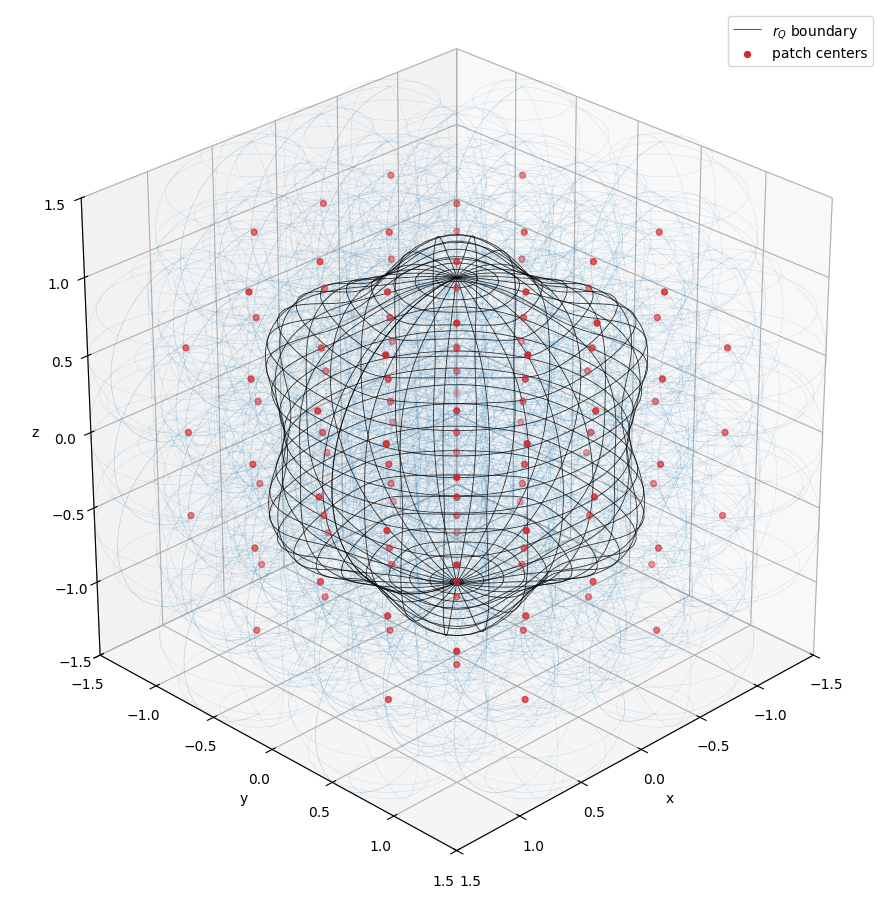

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pou_patch_cover_rQ(C, R, n_surface=80, n_sphere=24, show_centers=True):
    """
    C: (Np, 3) patch centers
    R: (Np,) patch radii
    """

    C = np.asarray(C)
    R = np.asarray(R)

    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection='3d')

    # =====================================================
    # 1. plot true rQ boundary
    # =====================================================
    theta = np.linspace(0, 2*np.pi, n_surface)
    phi = np.linspace(0, np.pi, n_surface)
    theta, phi = np.meshgrid(theta, phi)

    rq = rQ(theta, phi)

    Xq = rq * np.sin(phi) * np.cos(theta)
    Yq = rq * np.sin(phi) * np.sin(theta)
    Zq = rq * np.cos(phi)

    ax.plot_wireframe(
        Xq, Yq, Zq,
        rstride=3, cstride=3,
        color='black',
        linewidth=0.6,
        alpha=0.8,
        label=r'$r_Q$ boundary'
    )

    # =====================================================
    # 2. plot patch spheres
    # =====================================================
    us = np.linspace(0, 2*np.pi, n_sphere)
    vs = np.linspace(0, np.pi, n_sphere)
    us, vs = np.meshgrid(us, vs)

    sphere_x = np.sin(vs) * np.cos(us)
    sphere_y = np.sin(vs) * np.sin(us)
    sphere_z = np.cos(vs)

    for j in range(len(C)):
        x = C[j, 0] + R[j] * sphere_x
        y = C[j, 1] + R[j] * sphere_y
        z = C[j, 2] + R[j] * sphere_z

        ax.plot_wireframe(
            x, y, z,
            rstride=4, cstride=4,
            color='tab:blue',
            linewidth=0.35,
            alpha=0.18
        )

    # =====================================================
    # 3. centers
    # =====================================================
    if show_centers:
        ax.scatter(
            C[:, 0], C[:, 1], C[:, 2],
            s=18,
            color='tab:red',
            depthshade=True,
            label='patch centers'
        )

    # =====================================================
    # 4. visual settings
    # =====================================================
    ax.set_box_aspect([1, 1, 1])

    lim = 1.5
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_zlim([-lim, lim])

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

    ax.view_init(elev=28, azim=45)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_pou_patch_cover_rQ(C, R)

In [8]:
# compare with RFM_FD # 为了公平对比  nj = K  重新选取中心和半径
import numpy as np
from scipy.spatial import cKDTree

def estimate_uniform_R_from_target_n(X, target_n, safety=1.1):
    """
    根据目标 patch 内点数 target_n，估计统一半径 R。
    用每个点到第 target_n 个邻居的距离，再取中位数。
    """
    tree = cKDTree(X)
    target_n = min(target_n, X.shape[0])
    dists, _ = tree.query(X, k=target_n, workers=-1)
    if target_n == 1:
        r_each = dists
    else:
        r_each = dists[:, -1]
    R = safety * np.median(r_each)
    return R

def generate_centers_from_R(X, R, delta=0.2, margin=0.1):
    """
    根据统一半径 R 生成规则 Cartesian patch centers。
    3D 中:
        R = (1 + delta) * sqrt(3) * H / 2
    所以:
        H = 2R / ((1 + delta) sqrt(3))
    """
    H = 2.0 * R / ((1.0 + delta) * np.sqrt(3.0))
    xmin, ymin, zmin = X.min(axis=0) - margin
    xmax, ymax, zmax = X.max(axis=0) + margin
    gx = np.arange(xmin, xmax + H, H)
    gy = np.arange(ymin, ymax + H, H)
    gz = np.arange(zmin, zmax + H, H)
    Xg, Yg, Zg = np.meshgrid(gx, gy, gz, indexing="ij")
    C_all = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
    return C_all, H


def filter_centers_touching_X(C_all, X, R):
    """
    只保留半径 R 内至少包含一个 X 点的 patch center。
    """
    tree_X = cKDTree(X)
    keep = []
    for i, c in enumerate(C_all):
        idx = tree_X.query_ball_point(c, R)
        if len(idx) > 0:
            keep.append(i)
    return C_all[np.array(keep, dtype=int)]


def check_patch_cover_and_counts(C, R, X):
    """
    因为 X=Y，所以检查所有 X 是否被至少一个 patch 覆盖，
    并统计每个 patch 内点数。
    """
    tree_C = cKDTree(C)
    cover_lists = tree_C.query_ball_point(X, R)
    cover_count = np.array([len(v) for v in cover_lists])
    uncovered = np.where(cover_count == 0)[0]
    tree_X = cKDTree(X)
    nX = np.array([len(tree_X.query_ball_point(c, R)) for c in C])
    print("========== Patch report ==========")
    print("num patches:", len(C))
    print("R =", R)
    print("uncovered X:", len(uncovered), "/", len(X))
    print("cover count min/mean/max:",
          cover_count.min(), cover_count.mean(), cover_count.max())
    print("patch nX min/mean/max:",
          nX.min(), nX.mean(), nX.max())
    return uncovered, cover_count, nX

def generate_patches_X_equals_Y(
    X,
    target_n=120,
    delta=0.2,
    safety=1.1,
    margin=0.1,
    max_iter=10
):
    """
    X=Y 情况下，根据每个 patch 目标点数 target_n 生成 C 和统一 R。
    """
    X = np.asarray(X)
    # 1. 由目标点数估计统一半径
    R = estimate_uniform_R_from_target_n(
        X,
        target_n=target_n,
        safety=safety
    )
    for it in range(max_iter):
        print(f"\n--- iter {it} ---")

        # 2. 由 R 反推中心网格
        C_all, H = generate_centers_from_R(
            X,
            R,
            delta=delta,
            margin=margin
        )
        # 3. 保留和 X 有交集的 patch
        C = filter_centers_touching_X(C_all, X, R)
        # 4. 检查覆盖
        uncovered, cover_count, nX = check_patch_cover_and_counts(C, R, X)
        print("H =", H)
        print("target_n =", target_n)
        print("mean nX / target_n =", nX.mean() / target_n)
        if len(uncovered) == 0:
            break
        # 如果没覆盖完整，扩大半径
        R *= 1.05
    R_vec = R * np.ones(len(C))
    info = {
        "R": R,
        "H": H,
        "delta": delta,
        "num_patches": len(C),
        "target_n": target_n,
        "nX_min": nX.min(),
        "nX_mean": nX.mean(),
        "nX_max": nX.max(),
        "cover_min": cover_count.min(),
        "cover_mean": cover_count.mean(),
        "cover_max": cover_count.max(),
        "uncovered": len(uncovered),
    }
    return C, R_vec, info


In [9]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)
rho = R[0]
hidden_size = 50
Phi = PhiNet(input_size=3, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()

# # ===========================================================
u_func = lambda x, y, z: np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
f_func = lambda x, y, z: (3 * np.pi**2 - 1) * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
g_func = lambda x, y, z: u_func(x, y, z)

torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 100
N_boundary = 3000
overlap = 0.2

# generate points
X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
        N_patch_grid,
        N_local_per_patch,
        N_boundary,
        overlap,
        False
    )
X = np.vstack([X_inner, X_boundary])
ptch = {
    "C": C,
    "R": R
}
h = info["h"]

Yin = X_inner
Yb = X_boundary
Y = X

# X, Yin, Yb, info = generate_Y_for_oversampling_from_your_points(X_inner,X_boundary,C,R)
# Y = np.vstack([Yin, Yb])

# h_fixed = h/1.5
# Yin,Yb,info = generator_points_3d_grid(
#     h=h_fixed,
#     N_boundary=N_boundary,
#     visu=False
# )
# Y = np.vstack([Yin, Yb])
# np.save("Y_21017.npy",Y)
# Y = np.load("Y_21017.npy")
# M1 = 21017
# Y = np.load("Y_10509.npy")
# M1 = 10509
# Yin = Y[:M1,:]
# Yb = Y[M1:,:]


reg = 1e-13
order = 1
u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
# # ===========================================================
start = time.time()
UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
end = time.time()
print("Time for solving Helm =", end - start, "seconds")

print(u_true.shape,UY.shape)
error = np.abs(UY - u_true)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = relative_l2(UY ,u_true)
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')



Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 111
removed patches: 14
patch nX min/mean/max:1 / 139.59 / 497
X_inner: 3101
X_boundary: 3000


/home/chengwu/.conda/envs/py312/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Compile derivative matrix time = 15.792584657669067 seconds
Time for solving Helm = 23.937269926071167 seconds
(6101, 1) (6101, 1)
p = 1; L infity error in u_rfmfd: 1.179e-03
p = 1; Relative L2 error in u_rfmfd: 3.901e-04


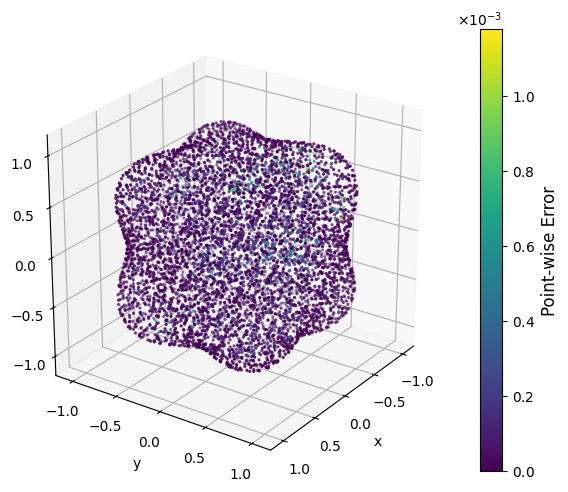

In [10]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

torch.cuda.empty_cache()

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=error,
    cmap='viridis',
    s=2
)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
# plt.savefig(f'./result/rfm_fd_p={order}_pointwise_error.eps', bbox_inches='tight')
plt.show()

In [11]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
hidden_size = 50
Phi = PhiNet(input_size=3, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()
# #===========================================================

# # ===========================================================
u_func = lambda x, y, z: np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
f_func = lambda x, y, z: (3 * np.pi**2 - 1) * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
g_func = lambda x, y, z: u_func(x, y, z)


key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)


start_order = 0
end_order = 5
overlap = 0.2
Length = end_order-start_order

H = np.zeros((Length,5))
E = np.zeros((Length,5))

Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill_distance is  0.20261351691995652
Compile derivative matrix time = 0.6659514904022217 seconds
p = 0; L infity error in u_rfmfd: 2.860e-01
Run Q=2, N_local_per_patch=35
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 105
removed patches: 20
patch nX min/mean/max:1 / 49.85 / 169
X_inner: 1078
X_boundary: 1000
fill_distance is  0.1681340723588302
Compile derivative matrix time = 2.00042462348938 seconds
p = 0; L infity error in u_rfmfd: 6.268e-02
Run Q=3, N_local_per_patch=60
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 109
removed patches: 16
patch nX min/mean/max:1 / 86.96 / 305
X_inner: 1853
X_boundary: 1800
fill_distance is  0.14048436629228492
Compile derivative matrix time = 7.2806551456

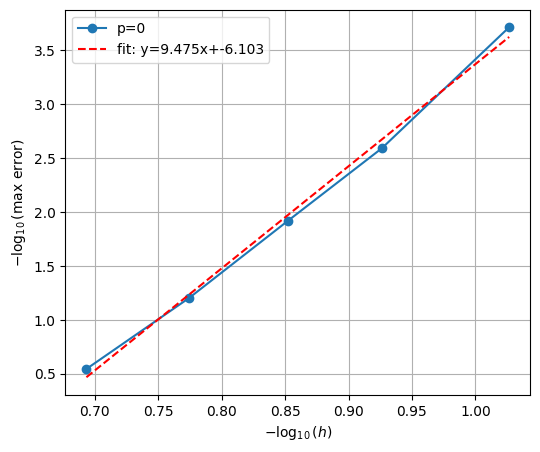

In [12]:
key = 100
np.random.seed(key)

NN = [ 20, 35, 60, 100, 200,]
BC = [ 600,1000,1800,3000,6000,]
RR = [1e-8, 1e-8, 1e-13, 1e-15, 1e-15]
start_order = 0
end_order = 5

Length = end_order-start_order


order = 0
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    ptch = {
    "C": C,
    "R": R
    }
    M1 = Yin.shape[0]
    h = info["h"]
    print("fill_distance is ", h)
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_pou_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg)
    error = np.max(np.abs(UY[:M1,:] - u_true[:M1,:]))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = h


row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    plt.show()



Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill_distance is  0.20261351691995652
Compile derivative matrix time = 0.8668050765991211 seconds
p = 1; L infity error in u_rfmfd: 2.638e-01
Run Q=2, N_local_per_patch=35
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 105
removed patches: 20
patch nX min/mean/max:1 / 49.85 / 169
X_inner: 1078
X_boundary: 1000
fill_distance is  0.1681340723588302
Compile derivative matrix time = 2.097151517868042 seconds
p = 1; L infity error in u_rfmfd: 6.039e-02
Run Q=3, N_local_per_patch=60
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 109
removed patches: 16
patch nX min/mean/max:1 / 86.96 / 305
X_inner: 1853
X_boundary: 1800
fill_distance is  0.14048436629228492
Compile derivative matrix time = 8.209431886

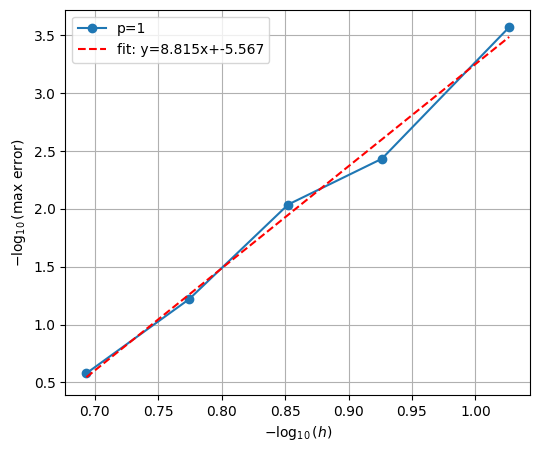

In [13]:
key = 100
np.random.seed(key)

NN = [ 20,  35,  60,  100, 200,]
BC = [ 600, 1000, 1800, 3100, 6000,]
RR = [1e-8, 1e-9, 1e-12, 1e-14, 1e-14]

order = 1
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    ptch = {
    "C": C,
    "R": R
    }
    M1 = Yin.shape[0]
    h = info["h"]
    print("fill_distance is ", h)
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg,order)
    error = np.max(np.abs(UY[:M1,:] - u_true[:M1,:]))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = h


row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    plt.show()



In [1]:
key = 100
np.random.seed(key)

# NN = 20
# BC = 600
# RR = 1e-10

# NN = 35
# BC = 1100
# RR = 1e-10

# NN = 60
# BC = 1800
# RR = 1e-15

# NN = 100
# BC = 3100
# RR = 1e-16

NN = 200
BC = 6000
RR = 1e-14


order = 4

N_patch_grid = 5
N_local_per_patch = NN
N_boundary = BC
overlap = 0.2

# generate points
X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
        N_patch_grid,
        N_local_per_patch,
        N_boundary,
        overlap,
        False
    )
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
ptch = {
"C": C,
"R": R
}
M1 = Yin.shape[0]
h = info["h"]
print("fill_distance is ", h)
reg = RR
if order == 0:
    UY,LI,L = rfm_fd_pou_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg)
else:
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
error = np.max(np.abs(UY[:M1,:] - u_true[:M1,:]))
print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')

NameError: name 'np' is not defined

Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill_distance is  0.20261351691995652
Compile derivative matrix time = 0.9166085720062256 seconds
p = 2; L infity error in u_rfmfd: 4.285e-01
Run Q=2, N_local_per_patch=35
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 105
removed patches: 20
patch nX min/mean/max:1 / 49.85 / 169
X_inner: 1078
X_boundary: 1000
fill_distance is  0.1681340723588302
Compile derivative matrix time = 2.1595659255981445 seconds
p = 2; L infity error in u_rfmfd: 7.812e-02
Run Q=3, N_local_per_patch=60
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 109
removed patches: 16
patch nX min/mean/max:1 / 86.96 / 305
X_inner: 1853
X_boundary: 1800
fill_distance is  0.14048436629228492
Compile derivative matrix time = 8.59252858

Compile derivative matrix time = 17.991865634918213 seconds
p = 2; L infity error in u_rfmfd: 8.676e-04
Run Q=5, N_local_per_patch=200
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 116
removed patches: 9
patch nX min/mean/max:1 / 269.78 / 993
X_inner: 6260
X_boundary: 6000
fill_distance is  0.09404486376746841
Compile derivative matrix time = 59.39291310310364 seconds
p = 2; L infity error in u_rfmfd: 1.599e-04
slope = 10.709806, bias = -7.059584


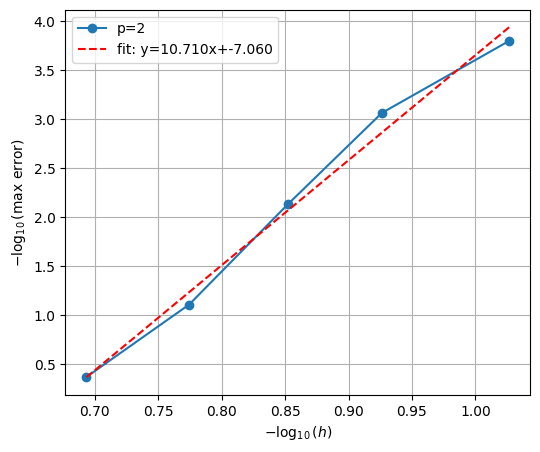

In [14]:
key = 100
np.random.seed(key)

# NN = [ 20,  50,  100, 200,]
# BC = [ 800, 1500, 3050, 6000,]

NN = [ 20, 35, 60, 100, 200,]
BC = [ 600,1000,1800,3100,6000,]
RR = [1e-11,1e-11,1e-14,1e-14,1e-16]

order = 2
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    ptch = {
    "C": C,
    "R": R
    }
    M1 = Yin.shape[0]
    h = info["h"]
    print("fill_distance is ", h)
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
    error = np.max(np.abs(UY[:M1,:] - u_true[:M1,:]))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = h


row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    plt.show()



Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill_distance is  0.20261351691995652
Compile derivative matrix time = 0.9674928188323975 seconds
p = 3; L infity error in u_rfmfd: 4.932e-01
Run Q=2, N_local_per_patch=35
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 105
removed patches: 20
patch nX min/mean/max:1 / 49.85 / 169
X_inner: 1078
X_boundary: 1100
fill_distance is  0.1681340723588302
Compile derivative matrix time = 2.4212193489074707 seconds
p = 3; L infity error in u_rfmfd: 5.718e-02
Run Q=3, N_local_per_patch=60
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 109
removed patches: 16
patch nX min/mean/max:1 / 86.96 / 305
X_inner: 1853
X_boundary: 1800
fill_distance is  0.14048436629228492
Compile derivative matrix time = 7.53912043

Compile derivative matrix time = 18.26018190383911 seconds
p = 3; L infity error in u_rfmfd: 2.282e-03
Run Q=5, N_local_per_patch=200
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 116
removed patches: 9
patch nX min/mean/max:1 / 269.78 / 993
X_inner: 6260
X_boundary: 6000
fill_distance is  0.09404486376746841
Compile derivative matrix time = 60.5131196975708 seconds
p = 3; L infity error in u_rfmfd: 1.405e-04
slope = 10.393949, bias = -6.868347


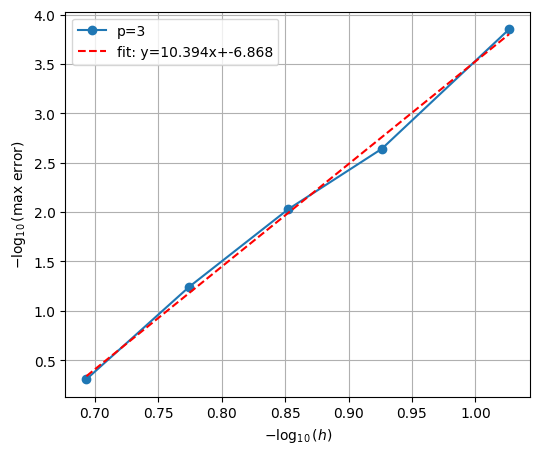

In [15]:
key = 100
np.random.seed(key)

NN = [ 20, 35, 60, 100, 200,]
BC = [ 600,1100,1800,3100,6000,]
RR = [1e-9,1e-11,1e-15,1e-15,1e-16]

order = 3
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    ptch = {
    "C": C,
    "R": R
    }
    M1 = Yin.shape[0]
    h = info["h"]
    print("fill_distance is ", h)
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg,order)
    error = np.max(np.abs(UY[:M1,:] - u_true[:M1,:]))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = h

row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    plt.show()



Run Q=1, N_local_per_patch=20
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 102
removed patches: 23
patch nX min/mean/max:1 / 29.54 / 97
X_inner: 620
X_boundary: 600
fill_distance is  0.20261351691995652
Compile derivative matrix time = 1.0545103549957275 seconds
p = 4; L infity error in u_rfmfd: 6.340e-01
Run Q=2, N_local_per_patch=35
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 105
removed patches: 20
patch nX min/mean/max:1 / 49.85 / 169
X_inner: 1078
X_boundary: 1100
fill_distance is  0.1681340723588302
Compile derivative matrix time = 2.5602238178253174 seconds
p = 4; L infity error in u_rfmfd: 8.042e-02
Run Q=3, N_local_per_patch=60
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 109
removed patches: 16
patch nX min/mean/max:1 / 86.96 / 305
X_inner: 1853
X_boundary: 1800
fill_distance is  0.14048436629228492
Compile derivative matrix time = 8.63187956

p = 4; L infity error in u_rfmfd: 2.453e-03
Run Q=5, N_local_per_patch=200
Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 116
removed patches: 9
patch nX min/mean/max:1 / 269.78 / 993
X_inner: 6260
X_boundary: 6000
fill_distance is  0.09404486376746841
Compile derivative matrix time = 67.19212198257446 seconds
p = 4; L infity error in u_rfmfd: 1.962e-04
slope = 10.424991, bias = -6.969060


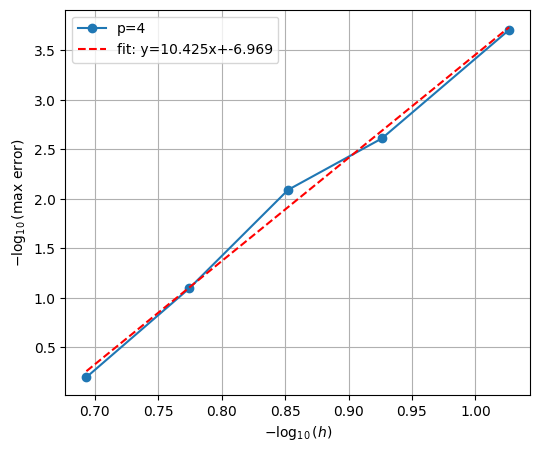

In [16]:
key = 100
np.random.seed(key)

# NN = [ 20, 40,  100, 200,]
# BC = [ 800,1200,2900,6000,]

NN = [ 20, 35, 60, 100, 200,]
BC = [ 600,1100,1800,2900,6000,]
RR = [1e-10,1e-10,1e-13,1e-15,1e-15]

order = 4
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = NN[qi]
    N_boundary = BC[qi]
    overlap = 0.2

    # generate points
    X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
            N_patch_grid,
            N_local_per_patch,
            N_boundary,
            overlap,
            False
        )
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    ptch = {
    "C": C,
    "R": R
    }
    M1 = Yin.shape[0]
    h = info["h"]
    print("fill_distance is ", h)
    u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
    reg = RR[qi]
    UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg,order)
    error = np.max(np.abs(UY[:M1,:] - u_true[:M1,:]))
    print(f'p = {order}; L infity error in u_rfmfd: {error.item():.3e}')
    # error_l2 = np.sqrt(np.mean((UY - u_true)**2))
    # print(f'p = {order}; L2 error in u_rfmfd: {error_l2.item():.3e}')
    E[order-start_order,qi] = error
    H[order-start_order,qi] = h


row = order - start_order
x = -np.log10(H[row, :])
y = -np.log10(E[row, :])
mask = np.isfinite(x) & np.isfinite(y) & (H[row, :] > 0) & (E[row, :] > 0)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6, 5))
    plt.plot(x[mask], y[mask], marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    plt.xlabel(r'$-\log_{10}(h)$')
    plt.ylabel(r'$-\log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


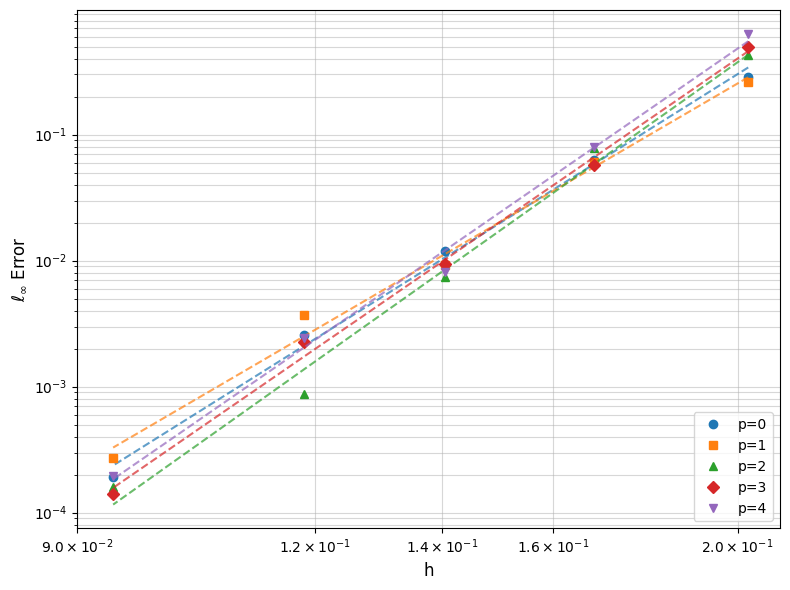

In [17]:
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = [f'p={start_order+0}', f'p={start_order+1}', f'p={start_order+2}', f'p={start_order+3}',f'p={start_order+4}']
plt.figure(figsize=(8, 6))

for i in range(Length):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')
    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)

ax = plt.gca()
xticks = np.array([9e-2, 1.2e-1, 1.4e-1,1.6e-1, 2e-1])
ax.set_xticks(xticks)
def sci_fmt(x, pos):
    if x == 0:
        return '0'
    exp = int(np.floor(np.log10(x)))
    coeff = x / 10**exp
    return r'$%.1f\times 10^{%d}$' % (coeff, exp)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(sci_fmt))
plt.xlabel('h', fontsize=12)
plt.ylabel(r'$\ell_\infty$ Error', fontsize=12)
ax.xaxis.set_minor_locator(ticker.NullLocator())
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./helm3d_rfmfd_pou_p=01234_convergence_scatter_overlap_hp_input3.eps', bbox_inches='tight')
plt.show()


In [ ]:
# markers = ['o', 's', '^', 'D', 'v']  
# colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
# labels = [f'p={start_order+0}', f'p={start_order+1}', f'p={start_order+2}', f'p={start_order+3}',f'p={start_order+4}']
# plt.figure(figsize=(8, 6))

# for i in range(end_order-start_order):
#     h = H[i, :]
#     e = E[i, :]
#     x = -1.0 / h   # -1/h
#     slope, intercept = np.polyfit(x, np.log(e), 1)
#     fit_e = np.exp(intercept + slope * x)
#     plt.semilogy(
#         x, e,
#         marker=markers[i],
#         linestyle='None',
#         color=colors[i],
#         label=f'{labels[i]}'
#     )
#     plt.semilogy(
#         x, fit_e,
#         linestyle='--',
#         color=colors[i],
#         alpha=0.7,
#         linewidth=1.5
#     )

# ax = plt.gca()
# xticks = -np.unique(1.0 / H.ravel())
# xticks = xticks[np.isfinite(xticks)]
# xticks = np.sort(xticks)
# ax.set_xticks(xticks)

# ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.1f}"))
# plt.xlabel('-1/h', fontsize=12)
# plt.ylabel('Relative $l_2$ Error', fontsize=12)
# ax.xaxis.set_minor_locator(ticker.NullLocator())
# plt.grid(True, which="both", ls="-", alpha=0.5)
# plt.legend(loc='lower right')
# plt.tight_layout()
# # plt.savefig('./result/helm3d_rfmfd_pou_p=01234_convergence_scatter_overlap_exp.eps', bbox_inches='tight')
# plt.show()


# operator learning

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import qmc
# =========================================================
# 1. star-shaped boundary
# =========================================================
def rQ(theta, phi):
    return np.sqrt(
        1
        + np.sin(2 * np.sin(phi) * np.cos(theta))**2
        * np.sin(2 * np.sin(phi) * np.sin(theta))**2
        * np.sin(2 * np.cos(phi))**2
    )
# =========================================================
# 2. inside test
# =========================================================
def inside_star(x, y, z, eps=1e-12):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arctan2(y, x)
    phi = np.arccos(np.clip(z / (r + eps), -1, 1))
    return r <= rQ(theta, phi)

# =========================================================
# 3. generate boundary points
# =========================================================
def generate_boundary_points(N_boundary=2000):
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_boundary)
    theta = 2 * np.pi * pts[:, 0]
    phi = np.arccos(1 - 2 * pts[:, 1])
    r = rQ(theta, phi)
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    return np.vstack([x, y, z]).T
# =========================================================
# 4. generate patch centers and H
# =========================================================
def generate_centers_auto_H(N_patch_grid, rQ, margin=0.1):
    """
    Returns
    -------
    C    : (N_patch_grid^3, 3)
    H    : scalar, max(Hx, Hy, Hz)
    """
    N_tmp = 20000
    sampler = qmc.Halton(d=2, scramble=False)
    pts = sampler.random(N_tmp)
    theta = 2.0 * np.pi * pts[:, 0]
    phi = np.arccos(1.0 - 2.0 * pts[:, 1])
    r = rQ(theta, phi)
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    x_min = x.min() - margin
    x_max = x.max() + margin
    y_min = y.min() - margin
    y_max = y.max() + margin
    z_min = z.min() - margin
    z_max = z.max() + margin
    Hx = (x_max - x_min) / (N_patch_grid - 1)
    Hy = (y_max - y_min) / (N_patch_grid - 1)
    Hz = (z_max - z_min) / (N_patch_grid - 1)
    H = max(Hx, Hy, Hz)
    Cx = np.linspace(x_min, x_max, N_patch_grid)
    Cy = np.linspace(y_min, y_max, N_patch_grid)
    Cz = np.linspace(z_min, z_max, N_patch_grid)
    Xg, Yg, Zg = np.meshgrid(Cx, Cy, Cz, indexing="ij")
    C = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
    return C, H

def compute_R_from_H_delta(H, delta):
    return (1 + delta) * np.sqrt(3) * H / 2

# =========================================================
# 5. generate inner points via patch + filter
# =========================================================
def generate_inner_points(C, R, N_local):
    X_list = []
    for c in C:
        sampler = qmc.Halton(d=3, scramble=False)
        pts = sampler.random(N_local)
        u, v, w = pts[:, 0], pts[:, 1], pts[:, 2]
        theta = 2 * np.pi * u
        phi = np.arccos(1 - 2 * v)
        r = R * (w ** (1/3))
        x = c[0] + r * np.sin(phi) * np.cos(theta)
        y = c[1] + r * np.sin(phi) * np.sin(theta)
        z = c[2] + r * np.cos(phi)
        X_list.append(np.vstack([x, y, z]).T)
    X_raw = np.vstack(X_list)
    # ======= 关键：投影回 star domain =======
    mask = inside_star(
        X_raw[:, 0],
        X_raw[:, 1],
        X_raw[:, 2]
    )
    X_inner = X_raw[mask]
    return X_inner

def remove_empty_patches_by_Xinner(C_raw, R, X_inner):
    """
    Remove patches that contain no interior points.
    Parameters
    ----------
    C_raw : (Np, 3)
        Patch centers
    R : scalar or (Np,)
        Patch radius
    X_inner : (N, 3)
        Interior points
    Returns
    -------
    C_new : (Np_new, 3)
    R_new : (Np_new,)
    keep  : (Np,) bool mask
    nX    : (Np,) number of points inside each patch
    """
    C_raw = np.asarray(C_raw)
    X_inner = np.asarray(X_inner)
    if np.isscalar(R):
        R_vec = np.full(C_raw.shape[0], R)
    else:
        R_vec = np.asarray(R)
    tree_X = cKDTree(X_inner)
    keep = np.zeros(C_raw.shape[0], dtype=bool)
    nX = np.zeros(C_raw.shape[0], dtype=int)
    for j, c in enumerate(C_raw):
        idx = tree_X.query_ball_point(c, R_vec[j])
        nX[j] = len(idx)
        if nX[j] > 0:
            keep[j] = True
    C_new = C_raw[keep]
    R_new = R_vec[keep]
    print(f"original patches: {C_raw.shape[0]}")
    print(f"kept patches: {C_new.shape[0]}")
    print(f"removed patches: {C_raw.shape[0] - C_new.shape[0]}")
    if np.any(keep):
        print("patch nX min/mean/max:" 
              f"{nX[keep].min()} / {nX[keep].mean():.2f} / {nX[keep].max()}")
    else:
        print("No patches kept!")
    return C_new, R_new, keep, nX
# =========================================================
# 6. 可视化函数
# =========================================================
def visualize_points(X_inner, X_boundary):

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    # ==========================
    # 1. 生成参考边界（仅用于 wireframe）
    # ==========================
    n_theta = 60
    n_phi = 60
    theta = np.linspace(0, 2*np.pi, n_theta)
    phi = np.linspace(0, np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi)
    r = rQ(theta, phi)
    X = r * np.sin(phi) * np.cos(theta)
    Y = r * np.sin(phi) * np.sin(theta)
    Z = r * np.cos(phi)
    ax.plot_wireframe(
        X, Y, Z,
        rstride=2, cstride=2,
        color='black',
        linewidth=0.5,
        alpha=0.8,
        zorder=0.5
    )
    # ==========================
    # 2. Boundary 点
    # ==========================
    ax.scatter(
        X_boundary[:, 0],
        X_boundary[:, 1],
        X_boundary[:, 2],
        s=1,
        color='blue',
        depthshade=True,
        zorder=2,
        label='Boundary points'
    )
    # ==========================
    # 3. 内点
    # ==========================
    ax.scatter(
        X_inner[::2, 0],
        X_inner[::2, 1],
        X_inner[::2, 2],
        s=1,
        color='red',
        alpha=0.7,
        depthshade=True,
        zorder=3,
        label='Interior points'
    )
    # ==========================
    # 4. 视觉设置
    # ==========================
    ticks = [-1, -0.5, 0, 0.5, 1]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.view_init(elev=35, azim=45)
    plt.tight_layout()
    plt.show()

# =========================================================
# 7. main
# =========================================================
def generator_points_3d_overlap(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap,
    visu
):

    X_boundary = generate_boundary_points(N_boundary)

    # =====================================================
    # 1. raw centers
    # =====================================================
    C_raw, H = generate_centers_auto_H(N_patch_grid, rQ, margin=0.1)
    h = H/(N_local_per_patch)**(1/3)
    info = {
        "H": H ,
        "h": h
            }

    print("Generator's C:", len(C_raw))
    # =====================================================
    # 2. compute R from overlap in 3D
    # =====================================================
    R = compute_R_from_H_delta(H, overlap) # scalar
    print("Generator's R =", R)
    # =====================================================
    # 3. inner points and filter C
    # =====================================================
    X_inner = generate_inner_points(C_raw, R, N_local_per_patch)
    C,R,_,_=remove_empty_patches_by_Xinner(C_raw, R, X_inner)
    print("X_inner:", len(X_inner))
    print("X_boundary:", len(X_boundary))
    # =====================================================
    # 5. visualization
    # =====================================================
    if visu:
        visualize_points(X_inner, X_boundary)

    return X_inner, X_boundary, C, R, info

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

#### to make the comparison justified with RFM-FD, make nj = K.  

def estimate_uniform_R_from_target_n(X, target_n, safety=1.1):
    """
    根据目标 patch 内点数 target_n，估计统一半径 R。
    用每个点到第 target_n 个邻居的距离，再取中位数。
    """
    tree = cKDTree(X)
    target_n = min(target_n, X.shape[0])
    dists, _ = tree.query(X, k=target_n, workers=-1)
    if target_n == 1:
        r_each = dists
    else:
        r_each = dists[:, -1]
    R = safety * np.median(r_each)
    return R

def generate_centers_from_R(X, R, delta=0.2, margin=0.1):
    """
    根据统一半径 R 生成规则 Cartesian patch centers。
    3D 中:
        R = (1 + delta) * sqrt(3) * H / 2
    所以:
        H = 2R / ((1 + delta) sqrt(3))
    """
    H = 2.0 * R / ((1.0 + delta) * np.sqrt(3.0))
    xmin, ymin, zmin = X.min(axis=0) - margin
    xmax, ymax, zmax = X.max(axis=0) + margin
    gx = np.arange(xmin, xmax + H, H)
    gy = np.arange(ymin, ymax + H, H)
    gz = np.arange(zmin, zmax + H, H)
    Xg, Yg, Zg = np.meshgrid(gx, gy, gz, indexing="ij")
    C_all = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
    return C_all, H

def filter_centers_touching_X(C_all, X, R):
    """
    只保留半径 R 内至少包含一个 X 点的 patch center。
    """
    tree_X = cKDTree(X)
    keep = []
    for i, c in enumerate(C_all):
        idx = tree_X.query_ball_point(c, R)
        if len(idx) > 0:
            keep.append(i)
    return C_all[np.array(keep, dtype=int)]


def check_patch_cover_and_counts(C, R, X):
    """
    所以检查所有 X 是否被至少一个 patch 覆盖，
    并统计每个 patch 内点数。
    """
    tree_C = cKDTree(C)
    cover_lists = tree_C.query_ball_point(X, R)
    cover_count = np.array([len(v) for v in cover_lists])
    uncovered = np.where(cover_count == 0)[0]
    tree_X = cKDTree(X)
    nX = np.array([len(tree_X.query_ball_point(c, R)) for c in C])
    print("========== Patch report ==========")
    print("num patches:", len(C))
    print("R =", R)
    print("uncovered X:", len(uncovered), "/", len(X))
    print("cover count min/mean/max:",
          cover_count.min(), cover_count.mean(), cover_count.max())
    print("patch nX min/mean/max:",
          nX.min(), nX.mean(), nX.max())
    return uncovered, cover_count, nX

def generate_patches_X_equals_Y(
    X,
    target_n=120,
    delta=0.2,
    safety=1.1,
    margin=0.1,
    max_iter=10
):
    """
    X=Y 情况下，根据每个 patch 目标点数 target_n 生成 C 和统一 R。
    """
    X = np.asarray(X)
    # 1. 由目标点数估计统一半径
    R = estimate_uniform_R_from_target_n(
        X,
        target_n=target_n,
        safety=safety
    )
    for it in range(max_iter):
        print(f"\n--- iter {it} ---")

        # 2. 由 R 反推中心网格
        C_all, H = generate_centers_from_R(
            X,
            R,
            delta=delta,
            margin=margin
        )
        # 3. 保留和 X 有交集的 patch
        C = filter_centers_touching_X(C_all, X, R)
        # 4. 检查覆盖
        uncovered, cover_count, nX = check_patch_cover_and_counts(C, R, X)
        print("H =", H)
        print("target_n =", target_n)
        print("mean nX / target_n =", nX.mean() / target_n)
        if len(uncovered) == 0:
            break
        # 如果没覆盖完整，扩大半径
        R *= 1.05
    R_vec = R * np.ones(len(C))
    info = {
        "R": R,
        "H": H,
        "delta": delta,
        "num_patches": len(C),
        "target_n": target_n,
        "nX_min": nX.min(),
        "nX_mean": nX.mean(),
        "nX_max": nX.max(),
        "cover_min": cover_count.min(),
        "cover_mean": cover_count.mean(),
        "cover_max": cover_count.max(),
        "uncovered": len(uncovered),
    }
    return C, R_vec, info


def remove_empty_patches(C, R, X_inner, X_boundary):
    """
    去掉球内没有任何 X_inner 或 X_boundary 的 patch centers.
    C: (Np, 3)
    R: (Np,) 或 scalar
    """
    C = np.asarray(C)
    R = np.asarray(R)
    X_all = np.vstack([X_inner, X_boundary])
    tree_X = cKDTree(X_all)
    keep = []
    for j, c in enumerate(C):
        rj = R[j] if R.ndim > 0 else R
        idx = tree_X.query_ball_point(c, rj)
        if len(idx) > 0:
            keep.append(j)
    keep = np.array(keep, dtype=int)
    C_new = C[keep]
    R_new = R[keep] if R.ndim > 0 else R * np.ones(len(C_new))
    print("original patches:", len(C))
    print("kept patches:", len(C_new))
    print("removed patches:", len(C) - len(C_new))
    return C_new, R_new, keep



import numpy as np
import torch
import torch.nn as nn
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial import KDTree, distance
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve,splu, eigs, LinearOperator, svds
from scipy.linalg import lstsq, lu_factor, lu_solve
from scipy.sparse import csc_matrix
import matplotlib.ticker as ticker
import time
dtype = torch.float64
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)


import numpy as np
from scipy.spatial import cKDTree

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(2.480142735337281)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sin(torch.pi * output)
        output = torch.cos(torch.pi * self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, 0, 0)
                    # nn.init.uniform_(m.bias, -torch.pi, -torch.pi)


def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    # plt.savefig('L.eps', bbox_inches='tight')
    plt.show()

def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

def wendland_C2_derivatives_3d(r, diff, R):
    """
    Delta phi(r_scaled) = 1/R^2 * [phi''(r_scaled)] + 2/r_scaled * phi'(r_scaled)]
    r:    (M, Nc)
    diff: (M, Nc, 3)
    R:    (Nc,)
    """
    eps = 1e-8
    M, Nc = r.shape
    mask = (r < 1).astype(float)
    phi_r_prime  = -20.0 * r * (1.0 - r)**3 * mask
    phi_r_double =  20.0 * (1.0 - r)**2 * (4.0*r - 1.0) * mask
    diff_norm = np.linalg.norm(diff, axis=2)
    diff_norm = np.maximum(diff_norm, eps)
    grad = np.zeros_like(diff)
    lap = np.zeros((M, Nc))
    for j in range(Nc):
        grad[:, j, :] = (
            phi_r_prime[:, j] / (diff_norm[:, j] * R[j])
        )[:, None] * diff[:, j, :]
        lap[:, j] = (
            phi_r_double[:, j]
            + 2.0 * phi_r_prime[:, j] / (r[:, j] + eps)
        ) / (R[j]**2)
    return grad, lap

def shepard_weights_with_derivatives_3d(x, ptch_C, ptch_R):
    """
    x:(M,3) ptch_C:(Np,3), ptch_R:(Np,)
    return
    (M,Np), (M,Np,3), (M,Np)
    """
    eps = 1e-12
    diff = x[:, None, :] - ptch_C[None, :, :]   # (M, Nc, 3)
    r_dist = np.linalg.norm(diff, axis=2)
    r_scaled = r_dist / ptch_R[None, :]
    phi = wendland_C2(r_scaled)
    sum_phi = np.sum(phi, axis=1, keepdims=True)
    sum_phi = np.maximum(sum_phi, 1e-8)
    W = phi / sum_phi
    # ===== 导数 =====
    grad_phi, lap_phi = wendland_C2_derivatives_3d(r_scaled, diff, ptch_R)
    # S = sum_j phi_j
    S = np.sum(phi, axis=1, keepdims=True)           # (M, 1)
    S = np.maximum(S, eps)
    # grad S, lap S
    grad_S = np.sum(grad_phi, axis=1, keepdims=True) # (M, 1, 3)
    lap_S = np.sum(lap_phi, axis=1, keepdims=True)   # (M, 1)
    # W_j = phi_j / S
    W = phi / S                                      # (M, Np)
    # ===== ∇W =====
    # grad W_j = grad_phi_j / S - phi_j grad_S / S^2
    grad_W = (grad_phi / S[:, :, None] - phi[:, :, None] * grad_S / (S[:, :, None] ** 2))
    # ===== ΔW =====
    # lap W_j = lap_phi_j / S - phi_j lap_S / S^2- 2 grad_phi_j · grad_S / S^2 + 2 phi_j |grad_S|^2 / S^3
    grad_phi_dot_grad_S = np.sum(grad_phi * grad_S,axis=2)   # (M, Np)
    grad_S_norm2 = np.sum(grad_S[:, 0, :] ** 2,axis=1,keepdims=True)  
    lap_W = (lap_phi / S- phi * lap_S / (S ** 2)- 2.0 * grad_phi_dot_grad_S / (S ** 2)+ 2.0 * phi * grad_S_norm2 / (S ** 3))
    return W, grad_W, lap_W

def dphi_wrt_y_3d_batch(phi_net, y, X, eps=1e-8):
    """
    1D Parameters
    ----------
    y : (n_j,3) or (1,3)
    X : (K,3)
    
    Returns
    -------
    phi_vals : (n_j, K)
    dphi_dy  : (n_j, K)
    d2phi_dy2: (n_j, K)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    # print("y.shape", y.shape, "X.shape", X.shape)
    y.requires_grad_(False)
    X.requires_grad_(False)
    # =========================================================
    # 1. pairwise difference and Euclidean distance
    # =========================================================
    diff = y[:, None, :] - X[None, :, :]          # (n_j, K, 3)
    r = torch.sqrt((diff ** 2).sum(dim=-1))  # (n_j, K)
    r = r.clamp(min=eps)  
    r.requires_grad_(True)
    # -------- forward --------
    phi_vals = phi_net(r)         # (n_j, K)

    # -------- φ'(r) --------
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True,
    )[0]   # (n_j, K)
    # -------- φ''(r) --------
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=False,
    )[0]   # (n_j, K)
    # 3d laplace
    with torch.no_grad():
        grad_phi = dphi_dr[..., None] * diff / r[..., None]
        lap_phi = d2phi_dr2 + (2.0 / (r)) * dphi_dr
        phi_np = phi_vals.detach().cpu().numpy()
        grad_np = grad_phi.detach().cpu().numpy()
        lap_np = lap_phi.detach().cpu().numpy()
        
    del diff, r, phi_vals, dphi_dr, d2phi_dr2, grad_phi, lap_phi

    if device.type == "cuda":
        torch.cuda.empty_cache()
    return phi_np, grad_np, lap_np


def dphi_wrt_y_3d_chunked(phi_net, Yj, Xj, chunk_size=256):
    phi_list = []
    grad_list = []
    lap_list = []
    for start in range(0, Yj.shape[0], chunk_size):
        end = min(start + chunk_size, Yj.shape[0])
        y_chunk = Yj[start:end]   # (chunk, 3)
        phi, grad, lap = dphi_wrt_y_3d_batch(
            phi_net, y_chunk, Xj
        )
        phi_list.append(phi)
        grad_list.append(grad)
        lap_list.append(lap)
    phi = np.vstack(phi_list)
    grad = np.vstack(grad_list)
    lap = np.vstack(lap_list)
    return phi, grad, lap


def poly3D(Z, order):
    """
    Z: (K, d)
    P: (K, Norder); 
    """
    K = Z.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    P = np.zeros((K, Norder))
    powers = np.arange(order + 1)
    X_pow = Z[:, 0:1] ** powers
    Y_pow = Z[:, 1:2] ** powers
    Z_pow = Z[:, 2:3] ** powers
    cnt = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                P[:, cnt] = X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k]
                cnt += 1        
    return P

def laplacian_poly3D(y, order):
    """
    y: (Np, d)
    lap: (Norder, Np); 
    """
    Np = y.shape[0]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    lap = np.zeros((Norder, Np))
    
    # 【核心优化】：同样预先计算 0 到 order 的所有幂次
    powers = np.arange(order + 1)
    X_pow = y[:, 0:1] ** powers
    Y_pow = y[:, 1:2] ** powers
    Z_pow = y[:, 2:3] ** powers
    curr = 0
    for i in range(order + 1):
        for j in range(order - i + 1):
            for k in range(order - i - j + 1):
                val = np.zeros(Np)
                if i >= 2:
                    val += (i * (i - 1)) * (X_pow[:, i - 2] * Y_pow[:, j] * Z_pow[:, k])
                if j >= 2:
                    val += (j * (j - 1)) * (X_pow[:, i] * Y_pow[:, j - 2] * Z_pow[:, k])
                if k >= 2:
                    val += (k * (k - 1)) * (X_pow[:, i] * Y_pow[:, j] * Z_pow[:, k - 2]) 
                lap[curr, :] = val
                curr += 1     
    return lap

def gradient_poly3D(y,order):
    """
    Parameters
    ----------
    y : (M, 3)
    Returns
    -------
    grad_x : (Norder, M)
    grad_y : (Norder, M)
    grad_z : (Norder, M)
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]  # (1,3)
    M = y.shape[0]
    x = y[:, 0]
    yv = y[:, 1]
    z = y[:, 2]
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    grad_x = np.zeros((Norder, M))
    grad_y = np.zeros((Norder, M))
    grad_z = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            for k in range(order + 1 - i - j):
                # ∂/∂x
                if i == 0:
                    grad_x[idx, :] = 0.0
                else:
                    grad_x[idx, :] = i * (x ** (i - 1)) * (yv ** j) * (z ** k)
                # ∂/∂y
                if j == 0:
                    grad_y[idx, :] = 0.0
                else:
                    grad_y[idx, :] = j * (x ** i) * (yv ** (j - 1)) * (z ** k)
                # ∂/∂z
                if k == 0:
                    grad_z[idx, :] = 0.0
                else:
                    grad_z[idx, :] = k * (x ** i) * (yv ** j) * (z ** (k - 1))
                idx += 1
    return grad_x, grad_y, grad_z


# (M,1)


In [ ]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve

def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    solve_A = build_wls_solver(A)
    alpha = solve_A(RHS)
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")
    A = A.tocsr()
    M, N = A.shape
    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 1.0 / (row_max + 1e-12)
    W = sp.diags(w, format='csr')
    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)
        if x.ndim == 1:
            x = x[:, None]
        return x
    return solve

def rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order):
    """
    -Laplace(u) - k^2 u = f, where k^2 = 1
    X:  (N,3)  RBF source points
    Yin: (M1,3) interior points
    Yb:  (M2,3) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: 0,1,2,3...
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    N = X.shape[0]
    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2
    Y = np.vstack((Yin, Yb))
    Norder = (order + 1) * (order + 2) * (order + 3) // 6
    Np = patch_C.shape[0]
    
    f_val =f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])  if callable(f_func) else f_func #(M1,)
    g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2]) if callable(g_func) else g_func
    RHS = np.concatenate((f_val, g_val)) #(M,)
    # print("RHS.shape",RHS.shape)
    L = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    O = np.zeros((Norder,Norder))
    # ==============================
    # main loop
    # ==============================
    tree_X = cKDTree(X)
    tree_Y = cKDTree(Y)

    W, grad_W, lap_W= shepard_weights_with_derivatives_3d(Y, patch_C, patch_R)
    # print("W.shape",W.shape)
    grad_Wx, grad_Wy, grad_Wz = grad_W[:,:,0], grad_W[:,:,1], grad_W[:,:,2]

    start = time.time()
    for j in range(Np):
        idx_X = np.array(tree_X.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_Y = np.array(tree_Y.query_ball_point(patch_C[j], patch_R[j]),dtype=int)
        idx_X.sort()
        idx_Y.sort()
        idx_Yin = idx_Y[idx_Y<M1]
        idx_Yb =  idx_Y[idx_Y>=M1]

        nj   = idx_X.shape[0]
        Mk   = idx_Y.shape[0]
        Mk1  = idx_Yin.shape[0]
        Mk2  = idx_Yb.shape[0]
        Xj   = X[idx_X]
        Yj   = Y[idx_Y]
        Yj_in = Y[idx_Yin]
        # print(idx_Y.shape,idx_X.shape, idx_Yb.shape)
        dist_ZZ = distance.cdist(Xj, Xj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # 内存不够, 分块计算导数
        if Yj.shape[0] * Xj.shape[0] >= 2e5:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_chunked(Phi, Yj, Xj, chunk_size=800)
        else:
            phi_xj, grad_phi, lap_phi = dphi_wrt_y_3d_batch(Phi, Yj, Xj, eps=1e-8) # (Mk,nj),(Mk,nj,3),(Mk,nj),
        # print("phi_xj",phi_xj.shape,"lap_phi",lap_phi.shape, "grad_phi",grad_phi.shape)
        # if not drop:
        grad_phi_x = grad_phi[:Mk1, :, 0].T  # (nj,Mk1)
        grad_phi_y = grad_phi[:Mk1, :, 1].T  # (nj,Mk1)
        grad_phi_z = grad_phi[:Mk1, :, 2].T  # (nj,Mk1)

        # AP
        P = poly3D(Xj, order) # (nj,Norder)
        # print("Phi_jj.shape",Phi_jj.shape, "P.shape", P.shape)
        AP = np.block([
            [Phi_jj, P],
            [P.T, O]
        ])
        # AP += reg * np.eye(nj + Norder)
        
        # RHS_lap, RHS_ide
        p_y = poly3D(Yj, order)                  # (Mk,Norder)
        lap_p = laplacian_poly3D(Yj_in, order)   # (Norder,Mk1)
        # print("p_y.shape",p_y.shape, "lap_p",lap_p.shape)
        RHS_lap = np.concatenate((lap_phi[:Mk1,:], lap_p.T), axis = 1).T  # (nj+Norder,Mk1)
        # print(RHS_lap.shape)
        RHS_ide = np.concatenate((phi_xj, p_y), axis = 1).T       # (nj+Norder,Mk)
        # RHS_grad
        grad_p_x,grad_p_y,grad_p_z = gradient_poly3D(Yj_in, order)  # (Norder,Mk1)
        # if not drop:
        RHS_grad_x = np.concatenate((grad_phi_x, grad_p_x), axis = 0) # (nj+Norder,Mk1)
        RHS_grad_y = np.concatenate((grad_phi_y, grad_p_y), axis = 0) # (nj+Norder,Mk1)
        RHS_grad_z = np.concatenate((grad_phi_z, grad_p_z), axis = 0) # (nj+Norder,Mk1)
        RHS_all = np.concatenate((RHS_lap,RHS_ide,RHS_grad_x,RHS_grad_y,RHS_grad_z),axis=1)       # (nj+Norder,Mk1+Mk+Mk1+Mk1+MK1)
        # else:
        #     RHS_all = np.concatenate((RHS_lap,RHS_ide),axis=1) # (nj+Norder,Mk1+Mk)
        # local operator weight
        # LU = lu_factor(AP)
        # w_all = lu_solve(LU, RHS_all)                 # (nj + Norder, Mk)
        w_all = lstsq(AP, RHS_all, cond=None)[0]
        w_lap = w_all[:, :Mk1]
        w_ide = w_all[:, Mk1:Mk1+Mk]
        # if not drop:
        w_grad_x = w_all[:, Mk1+Mk:2*Mk1+Mk]
        w_grad_y = w_all[:, 2*Mk1+Mk:3*Mk1+Mk]
        w_grad_z = w_all[:, 3*Mk1+Mk:]
        # Shepard weight
        win = W[idx_Yin,j][None, :]  # (1, Mk1)
        # if not drop:
        win_gradx = grad_Wx[idx_Yin,j][None, :]  # (1, Mk1)
        win_grady = grad_Wy[idx_Yin,j][None, :]  # (1, Mk1)
        win_gradz = grad_Wz[idx_Yin,j][None, :]  # (1, Mk1)
        win_lap = lap_W[idx_Yin,j][None, :]      # (1, Mk1)
        # Laplace (nj,Mk1)
        # if not drop:
        Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk1]+ 2 * win_grady * w_grad_y[:nj,:Mk1] + 2 * win_gradz * w_grad_z[:nj,:Mk1] + win * w_lap[:nj,:Mk1] + win_lap * w_ide[:nj,:Mk1])  # (nj, Mk_1)
        # else: 
        # Laplace =  win * w_lap[:nj,:Mk1]
        I = win * w_ide[:nj,:Mk1]          # (nj, Mk1)
        # --- boundary condtion
        wbc = W[idx_Yb,j][None, :]     # (1, Mk2)
        Op_bc = wbc * w_ide[:nj,Mk1:]  # (nj, Mk2)
        # --- LI 
        wvec = W[idx_Y, j][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]      # (nj,Mk)

        L[np.ix_(idx_Yin, idx_X)] = L[np.ix_(idx_Yin, idx_X)] - Laplace.T - I.T
        L[np.ix_(idx_Yb, idx_X)] = L[np.ix_(idx_Yb, idx_X)] + Op_bc.T
        
        LI[np.ix_(idx_Y, idx_X)] = LI[np.ix_(idx_Y, idx_X)] + IDE.T

    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
        
    L = L.tocsc()
    LI = LI.tocsc()
    # cond_L = np.linalg.cond(L.tocsr().todense())
    # print(f" L's condition number:, {cond_L}")
    # cond_LI = np.linalg.cond(LI.tocsr().todense())
    # print(f" LI's condition number:, {cond_LI}")
    # spy_like_matlab(L)
    # ==============================
    # solve
    # ==============================

    if M == N:
        LU1 = splu(L, permc_spec='COLAMD')
        UX = LU1.solve(RHS)
    else:
        # least squares: solve column by column
        solve_L = build_wls_solver(L)
        UX = solve_L(RHS).squeeze(-1)
        print(UX.shape)
        # Q, R = np.linalg.qr(L.toarray(), mode='reduced')
        # UX = np.linalg.solve(R, Q.T @ RHS)
    # -------------------------
    # Evaluate at Y
    # -------------------------
    UY = LI @ UX # (M,Q)

    return UY[:,None],LI,L


def test_solver(L, LI, RHS):
    """
    L  : (M,N) sparse operator matrix
    LI : (M,N) sparse interpolation matrix
    RHS: (M,Q) numpy array

    Returns
    -------
    UY : (M,Q) numpy array
    """
    L = L.tocsr()
    LI = LI.tocsr()

    M, N = L.shape
    Q = RHS.shape[1]
    # -------------------------
    # Solve L UX = RHS
    # -------------------------
    if M == N:
        # spsolve supports multiple RHS
        UX = spsolve(L, RHS)          # (N,Q)
    else:
        # least squares: solve column by column
        solve_L = build_wls_solver(L)
        UX = solve_L(RHS) # (N,Q)
        print(UX.shape)
        # Q, R = np.linalg.qr(L.toarray(), mode='reduced')
        # UX = np.linalg.solve(R, Q.T @ RHS)
    # -------------------------
    # Evaluate at Y
    # -------------------------
    UY = LI @ UX # (M,Q)

    return UY


In [ ]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double()

u_func = lambda x, y, z: np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
g_func = lambda x, y, z: u_func(x, y, z)
# #===========================================================
data = np.load('./data/orig_nodes_results_on_X_generated_by_overlap.npz') #coords, interior_idx, boundary_idx, u_new, f_new  


p, f_new, u_new, index_in, index_bc = data['coords'],data['f_new'],data['u_new'],data['interior_idx'],data['boundary_idx']  # sigma2 = 0.1, l = 0.15
index_in, index_bc = index_in.reshape(-1), index_bc.reshape(-1)
# print(index_in)
# print(p.shape,f_new.shape) # (21523, 3) (21523, 100)
# print(index_in.shape, index_bc.shape) #(11142,) (10381,)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]
M1 = M - M2

testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_func = f_new[index_in,testnum]
print("f_func.shape",f_func.shape)


u_true = u_new[:,testnum]
u_true = np.concatenate([u_true[index_in,None],u_true[index_bc,None]],axis=0)
print("u_true's shape",u_true.shape)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
# X = p
torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 150
N_boundary = 3000
overlap = 0.2

# generate points
X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
        N_patch_grid,
        N_local_per_patch,
        N_boundary,
        overlap,
        False
    )
X = np.vstack([X_inner, X_boundary])

K = 200
C_pou, R_pou, info = generate_patches_X_equals_Y(X, target_n= K,delta=0.2,
                                                safety=1.1,margin=0.1)
ptch = {
    "C": C_pou,
    "R": R_pou
}

reg = 1e-13
order = 3

# # ===========================================================
start = time.time()
UY,LI,L = rfm_fd_pou_poly_solve_helmholtz_3d(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order)
end = time.time()
print("Time for solving Helm =", end - start, "seconds")
print(u_true.shape,UY.shape)
error = np.abs(UY- u_true)[:M1,:] 
error_bc = np.abs(UY- u_true)[M1:,:]
print(f"error on boundary is  {error_bc.max().item():.3e}")
print(f'p = {order}; L infity error in u_rfmfd_pou: {error.max().item():.3e}')
error_u = relative_l2(UY[:M1,:] ,u_true[:M1,:])
print(f'p = {order}; Relative L2 error in u_rfmfd_pou: {error_u.item():.3e}')


In [ ]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:M1, 0], Y[:M1, 1], Y[:M1, 2],
    c=error[:,:],
    cmap='viridis',
    s=2
)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
plt.show()

In [ ]:
import time
E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
f_vec = f_new[index_in,:] 
g_vec = u_new[index_bc,:]

u_true = u_new
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
print(u_true.shape, f_vec.shape, g_vec.shape)
RHS = np.concatenate([f_vec,g_vec],axis = 0 )

start_time = time.time()
UY = test_solver(L, LI, RHS)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")

error_inf = np.abs(UY - u_true)
E_inf =  np.max(error_inf,axis = 0)
error_L2 = np.linalg.norm(UY - u_true, axis = 0) / np.linalg.norm(u_true, axis =0)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

np.random.seed(100)
q = np.random.randint(0,100)

import matplotlib.colors as mcolors

v_min = min(u_true[:, q].min(), UY[:, q].min())
v_max = max(u_true[:, q].max(), UY[:, q].max())
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)

In [ ]:
# plot_3d_scalar
# u_fem

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=u_true[:, q].reshape(-1),
    cmap='viridis',
    s=2
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label('u_fem')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
fig.savefig(f'./result/helm3d_rfmfdpou_p={order}_u_fem.eps', bbox_inches='tight')
plt.show()

# u_rfmfd_pou
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=UY[:, q].reshape(-1),
    cmap='viridis',
    s=2
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label('u_rfmfd_pou')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
fig.savefig(f'./result/helm3d_rfmfdpou_p={order}_u_rfm_fd_pou.eps',bbox_inches='tight')

plt.show()

# absolute error
error_inf = np.abs(UY - u_true)
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=error_inf[:, q].reshape(-1),
    cmap='viridis',
    s=2
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label('absolute error')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
fig.savefig(f'./result/helm3d_rfmfdpou_p={order}_absolute_error.eps', bbox_inches='tight')
plt.show()
print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")


In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse import lil_matrix
from scipy.spatial import cKDTree


# ============================================================
# 1. Wendland C2 Shepard weights in 3D
# ============================================================

def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r) ** 4


def wendland_C2_derivatives_3d(r, diff, R):
    """
    r:    (M, Np), scaled distance |x-c_j|/R_j
    diff: (M, Np, 3), physical x-c_j
    R:    (Np,)
    """
    eps = 1e-12
    M, Np = r.shape

    mask = (r < 1.0).astype(float)

    # phi(r) = (4r+1)(1-r)^4
    phi_r_prime = -20.0 * r * (1.0 - r) ** 3 * mask
    phi_r_double = 20.0 * (1.0 - r) ** 2 * (4.0 * r - 1.0) * mask

    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.maximum(dist, eps)

    grad = np.zeros_like(diff)
    lap = np.zeros((M, Np))

    for j in range(Np):
        # grad_x phi(|x-c|/R)
        grad[:, j, :] = (
            phi_r_prime[:, j] / (dist_safe[:, j] * R[j])
        )[:, None] * diff[:, j, :]

        # Delta_x phi(|x-c|/R) in 3D
        lap[:, j] = (
            phi_r_double[:, j]
            + 2.0 * phi_r_prime[:, j] / np.maximum(r[:, j], eps)
        ) / (R[j] ** 2)

        # At r=0, smooth radial 3D limit:
        # Delta phi(r/R) = 3 phi''(0) / R^2.
        near_zero = r[:, j] < eps
        if np.any(near_zero):
            lap[near_zero, j] = 3.0 * phi_r_double[near_zero, j] / (R[j] ** 2)
            grad[near_zero, j, :] = 0.0

    return grad, lap


def shepard_weights_with_derivatives_3d(x, patch_C, patch_R):
    """
    x:       (M,3)
    patch_C: (Np,3)
    patch_R: (Np,)

    returns:
        W:      (M,Np)
        grad_W: (M,Np,3)
        lap_W:  (M,Np)
    """
    eps = 1e-12

    diff = x[:, None, :] - patch_C[None, :, :]     # (M,Np,3)
    dist = np.linalg.norm(diff, axis=2)            # (M,Np)
    r_scaled = dist / patch_R[None, :]

    phi = wendland_C2(r_scaled)

    grad_phi, lap_phi = wendland_C2_derivatives_3d(
        r_scaled, diff, patch_R
    )

    S = np.sum(phi, axis=1, keepdims=True)
    S = np.maximum(S, eps)

    grad_S = np.sum(grad_phi, axis=1, keepdims=True)  # (M,1,3)
    lap_S = np.sum(lap_phi, axis=1, keepdims=True)    # (M,1)

    W = phi / S

    grad_W = (
        grad_phi / S[:, :, None]
        - phi[:, :, None] * grad_S / (S[:, :, None] ** 2)
    )

    grad_phi_dot_grad_S = np.sum(grad_phi * grad_S, axis=2)
    grad_S_norm2 = np.sum(grad_S[:, 0, :] ** 2, axis=1, keepdims=True)

    lap_W = (
        lap_phi / S
        - phi * lap_S / (S ** 2)
        - 2.0 * grad_phi_dot_grad_S / (S ** 2)
        + 2.0 * phi * grad_S_norm2 / (S ** 3)
    )

    return W, grad_W, lap_W


# ============================================================
# 2. Local random Fourier feature network / basis
# ============================================================

class LocalRFF3D:
    """
    Local random Fourier feature basis on reference patch.

    Input:
        Xhat: (M,3), reference coordinates:
              Xhat = (X - patch_center) / patch_radius

    Features:
        sin(a_m · Xhat + b_m), cos(a_m · Xhat + b_m)

    Local approximation:
        u_j(x) = sum_m c_m phi_m((x-c_j)/rho_j)
    """

    def __init__(
        self,
        n_freq,
        omega=1.0,
        seed=None,
        use_sincos=True,
        distribution="gaussian",
    ):
        self.n_freq = int(n_freq)
        self.omega = float(omega)
        self.use_sincos = bool(use_sincos)
        self.distribution = distribution

        rng = np.random.default_rng(seed)

        if distribution == "gaussian":
            # a_m ~ N(0, omega^2 I)
            self.A = self.omega * rng.standard_normal((self.n_freq, 3))

        elif distribution == "uniform_sphere":
            # random directions with frequency magnitude omega
            V = rng.standard_normal((self.n_freq, 3))
            V /= np.linalg.norm(V, axis=1, keepdims=True) + 1e-14
            self.A = self.omega * V

        elif distribution == "uniform_ball":
            # frequencies uniformly in [-omega, omega]^3
            self.A = rng.uniform(
                -self.omega, self.omega, size=(self.n_freq, 3)
            )

        else:
            raise ValueError(
                "distribution must be 'gaussian', 'uniform_sphere', or 'uniform_ball'"
            )

        self.b = rng.uniform(0.0, 2.0 * np.pi, size=(self.n_freq,))
        self.A2 = np.sum(self.A ** 2, axis=1)

    @property
    def n_features(self):
        if self.use_sincos:
            return 2 * self.n_freq
        return self.n_freq

    def eval_all_hat(self, Xhat, rho):
        """
        Evaluate value, physical gradient, and physical Laplacian.

        Xhat: (M,3)
        rho:  patch physical radius

        returns:
            F0:    (M,Mf)
            Fx:    (M,Mf)
            Fy:    (M,Mf)
            Fz:    (M,Mf)
            Flap:  (M,Mf)
        """
        Xhat = np.asarray(Xhat, dtype=np.float64)
        if Xhat.ndim == 1:
            Xhat = Xhat[None, :]

        Z = Xhat @ self.A.T + self.b[None, :]    # (M,n_freq)

        sinZ = np.sin(Z)
        cosZ = np.cos(Z)

        if self.use_sincos:
            F0 = np.concatenate([sinZ, cosZ], axis=1)

            Fx_hat = np.concatenate(
                [
                    cosZ * self.A[None, :, 0],
                    -sinZ * self.A[None, :, 0],
                ],
                axis=1,
            )
            Fy_hat = np.concatenate(
                [
                    cosZ * self.A[None, :, 1],
                    -sinZ * self.A[None, :, 1],
                ],
                axis=1,
            )
            Fz_hat = np.concatenate(
                [
                    cosZ * self.A[None, :, 2],
                    -sinZ * self.A[None, :, 2],
                ],
                axis=1,
            )

            Flap_hat = np.concatenate(
                [
                    -sinZ * self.A2[None, :],
                    -cosZ * self.A2[None, :],
                ],
                axis=1,
            )

        else:
            F0 = cosZ

            Fx_hat = -sinZ * self.A[None, :, 0]
            Fy_hat = -sinZ * self.A[None, :, 1]
            Fz_hat = -sinZ * self.A[None, :, 2]
            Flap_hat = -cosZ * self.A2[None, :]

        # Chain rule:
        # x = c + rho * xhat
        # grad_x = rho^{-1} grad_xhat
        # Delta_x = rho^{-2} Delta_xhat
        Fx = Fx_hat / rho
        Fy = Fy_hat / rho
        Fz = Fz_hat / rho
        Flap = Flap_hat / (rho ** 2)

        return F0, Fx, Fy, Fz, Flap


# ============================================================
# 3. WLS / ridge global solver
# ============================================================

def build_wls_solver_ridge(
    A,
    reg=1e-12,
    atol=1e-11,
    btol=1e-11,
    maxiter=20000,
    row_scale_type="l2",
):
    """
    Solve min ||W(Ax-b)||^2 + reg ||x||^2 using LSMR.

    A: sparse matrix, shape (M,N)
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape

    if row_scale_type == "l2":
        row_norm = np.sqrt(A.multiply(A).sum(axis=1)).A.ravel()
    elif row_scale_type == "max":
        row_norm = np.abs(A).max(axis=1).toarray().ravel()
    else:
        raise ValueError("row_scale_type must be 'l2' or 'max'")

    row_scale = 1.0 / np.maximum(row_norm, 1e-14)
    W = sp.diags(row_scale, format="csr")
    Aw = W @ A

    if reg > 0:
        A_aug = sp.vstack(
            [
                Aw,
                np.sqrt(reg) * sp.eye(N, format="csr"),
            ],
            format="csr",
        )
    else:
        A_aug = Aw

    def solve(rhs):
        rhs = np.asarray(rhs, dtype=np.float64)

        single_rhs = False
        if rhs.ndim == 1:
            rhs = rhs[:, None]
            single_rhs = True

        if rhs.shape[0] != M:
            raise ValueError(
                f"RHS shape mismatch: got {rhs.shape[0]}, expected {M}"
            )

        X = np.empty((N, rhs.shape[1]), dtype=np.float64)

        for k in range(rhs.shape[1]):
            bw = row_scale * rhs[:, k]

            if reg > 0:
                b_aug = np.concatenate([bw, np.zeros(N)])
            else:
                b_aug = bw

            sol = spla.lsmr(
                A_aug,
                b_aug,
                atol=atol,
                btol=btol,
                maxiter=maxiter,
            )

            X[:, k] = sol[0]

            print(
                f"LSMR rhs {k}: istop={sol[1]}, iters={sol[2]}, "
                f"normr={sol[3]:.3e}, normar={sol[4]:.3e}, condA={sol[6]:.3e}"
            )

        return X[:, 0] if single_rhs else X

    return solve


# ============================================================
# 4. RFF-PU Helmholtz solver in 3D
# ============================================================

def rff_pou_solve_helmholtz_3d(
    ptch,
    Yin,
    Yb,
    f_func,
    g_func,
    n_freq=100,
    omega=1.0,
    reg=1e-12,
    seed=1234,
    use_sincos=True,
    distribution="gaussian",
    row_scale_type="l2",
    atol=1e-11,
    btol=1e-11,
    maxiter=20000,
    return_matrix=True,
):
    """
    RFF-PU collocation solver for:

        -Delta u - u = f       in Omega
         u = g                 on boundary

    Unknown:
        local random Fourier feature coefficients c_{j,m}

    Approximation:
        u(x) = sum_j W_j(x) * u_j(x)
             = sum_j W_j(x) * sum_m c_{j,m} phi_{j,m}((x-C_j)/R_j)

    Parameters
    ----------
    ptch:
        dict with
            ptch["C"]: (Np,3), patch centers
            ptch["R"]: (Np,), patch radii

    Yin:
        (M1,3), interior collocation points

    Yb:
        (M2,3), boundary collocation points

    f_func, g_func:
        callables f(x,y,z), g(x,y,z), or arrays

    n_freq:
        number of random frequency vectors per patch

    omega:
        frequency scale on reference patch

    reg:
        global ridge regularization

    returns
    -------
    UY:
        (M,1), predicted values on Y=[Yin;Yb]

    LI:
        sparse evaluation matrix so that UY = LI @ coeff

    L:
        sparse PDE/boundary collocation matrix

    coeff:
        feature coefficient vector
    """
    patch_C = np.asarray(ptch["C"], dtype=np.float64)
    patch_R = np.asarray(ptch["R"], dtype=np.float64)

    Yin = np.asarray(Yin, dtype=np.float64)
    Yb = np.asarray(Yb, dtype=np.float64)

    M1 = Yin.shape[0]
    M2 = Yb.shape[0]
    M = M1 + M2

    Y = np.vstack([Yin, Yb])

    Np = patch_C.shape[0]

    # RHS
    if callable(f_func):
        f_val = f_func(Yin[:, 0], Yin[:, 1], Yin[:, 2])
    else:
        f_val = f_func

    if callable(g_func):
        g_val = g_func(Yb[:, 0], Yb[:, 1], Yb[:, 2])
    else:
        g_val = g_func

    f_val = np.asarray(f_val, dtype=np.float64).reshape(-1)
    g_val = np.asarray(g_val, dtype=np.float64).reshape(-1)

    RHS = np.concatenate([f_val, g_val])

    # One RFF basis per patch
    rff_list = [
        LocalRFF3D(
            n_freq=n_freq,
            omega=omega,
            seed=seed + 10007 * j,
            use_sincos=use_sincos,
            distribution=distribution,
        )
        for j in range(Np)
    ]

    Mf = rff_list[0].n_features
    N_unknown = Np * Mf

    print(f"Np = {Np}, Mf per patch = {Mf}, total unknowns = {N_unknown}")
    print(f"M equations = {M} = {M1} interior + {M2} boundary")

    L = lil_matrix((M, N_unknown), dtype=np.float64)
    LI = lil_matrix((M, N_unknown), dtype=np.float64)

    tree_Y = cKDTree(Y)

    # Physical Shepard weights and derivatives
    W, grad_W, lap_W = shepard_weights_with_derivatives_3d(
        Y, patch_C, patch_R
    )

    grad_Wx = grad_W[:, :, 0]
    grad_Wy = grad_W[:, :, 1]
    grad_Wz = grad_W[:, :, 2]

    for j in range(Np):
        xc = patch_C[j]
        rho = patch_R[j]
        rff = rff_list[j]

        idx_Y = np.array(
            tree_Y.query_ball_point(xc, rho),
            dtype=int,
        )
        idx_Y.sort()

        if idx_Y.size == 0:
            continue

        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]

        col0 = j * Mf
        col1 = (j + 1) * Mf
        cols = np.arange(col0, col1)

        # =====================================================
        # Evaluation matrix LI on all local Y
        # =====================================================
        Yj = Y[idx_Y]
        Yj_hat = (Yj - xc) / rho

        F0_all, _, _, _, _ = rff.eval_all_hat(Yj_hat, rho)

        w_all = W[idx_Y, j][:, None]
        IDE = w_all * F0_all

        LI[np.ix_(idx_Y, cols)] = LI[np.ix_(idx_Y, cols)] + IDE

        # =====================================================
        # Interior PDE rows
        # =====================================================
        if idx_Yin.size > 0:
            Yin_j = Y[idx_Yin]
            Yin_hat = (Yin_j - xc) / rho

            F0_in, Fx_in, Fy_in, Fz_in, Flap_in = rff.eval_all_hat(
                Yin_hat, rho
            )

            win = W[idx_Yin, j][:, None]
            wx = grad_Wx[idx_Yin, j][:, None]
            wy = grad_Wy[idx_Yin, j][:, None]
            wz = grad_Wz[idx_Yin, j][:, None]
            wlap = lap_W[idx_Yin, j][:, None]

            # Delta(W_j u_j)
            Laplace_Wu = (
                wlap * F0_in
                + 2.0 * wx * Fx_in
                + 2.0 * wy * Fy_in
                + 2.0 * wz * Fz_in
                + win * Flap_in
            )

            # -Delta(W_j u_j) - W_j u_j
            Op_in = -Laplace_Wu - win * F0_in

            L[np.ix_(idx_Yin, cols)] = L[np.ix_(idx_Yin, cols)] + Op_in

        # =====================================================
        # Boundary rows
        # =====================================================
        if idx_Yb.size > 0:
            Yb_j = Y[idx_Yb]
            Yb_hat = (Yb_j - xc) / rho

            F0_b, _, _, _, _ = rff.eval_all_hat(Yb_hat, rho)

            wb = W[idx_Yb, j][:, None]
            Op_b = wb * F0_b

            L[np.ix_(idx_Yb, cols)] = L[np.ix_(idx_Yb, cols)] + Op_b

    L = L.tocsr()
    LI = LI.tocsr()

    print("L shape =", L.shape, "nnz =", L.nnz)
    print("LI shape =", LI.shape, "nnz =", LI.nnz)

    solve_L = build_wls_solver_ridge(
        L,
        reg=reg,
        atol=atol,
        btol=btol,
        maxiter=maxiter,
        row_scale_type=row_scale_type,
    )

    coeff = solve_L(RHS)

    residual = L @ coeff - RHS
    print("global residual inf =", np.linalg.norm(residual, np.inf))
    print("interior residual inf =", np.linalg.norm(residual[:M1], np.inf))
    print("boundary residual inf =", np.linalg.norm(residual[M1:], np.inf))

    UY = LI @ coeff
    UY = UY.reshape(-1, 1)

    if return_matrix:
        return UY, LI, L, coeff, rff_list
    return UY


# ============================================================
# 5. Optional error helper
# ============================================================

def relative_l2(u_pred, u_true):
    u_pred = np.asarray(u_pred).reshape(-1)
    u_true = np.asarray(u_true).reshape(-1)
    return np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)

In [9]:

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

# # ===========================================================
u_func = lambda x, y, z: np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
f_func = lambda x, y, z: (3 * np.pi**2 - 1) * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)
g_func = lambda x, y, z: u_func(x, y, z)

torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 4000
overlap = 0.2

# generate points
X_inner, X_boundary, C, R, info = generator_points_3d_overlap(
        N_patch_grid,
        N_local_per_patch,
        N_boundary,
        overlap,
        False
    )
X = np.vstack([X_inner, X_boundary])
ptch = {
    "C": C,
    "R": R
}
h = info["h"]

# h_fixed = h/1.5
# Yin,Yb,info = generator_points_3d_grid(
#     h=h_fixed,
#     N_boundary=N_boundary,
#     visu=False
# )
# Y = np.vstack([Yin, Yb])
# np.save("Y.npy",Y)
Y = np.load("Y.npy")
M1 = 21017
Yin = Y[:M1,:]
Yb = Y[M1:,:]
# #===========================================================
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)
# #===========================================================
reg = 1e-14
order = 1
u_true = u_func(Y[:,0:1], Y[:,1:2],Y[:,2:3])
# # ===========================================================
start = time.time()

UY, LI, L, coeff, rff_list = rff_pou_solve_helmholtz_3d(
    ptch=ptch,
    Yin=Yin,
    Yb=Yb,
    f_func=f_func,
    g_func=g_func,
    n_freq=100,
    omega=2.0,
    reg=1e-12,
    seed=1234,
    use_sincos=True,
    distribution="gaussian",
    row_scale_type="l2",
    atol=1e-11,
    btol=1e-11,
    maxiter=20000,
)
end = time.time()

print("Time for solving Helm =", end - start, "seconds")

print(u_true.shape,UY.shape)
error = np.abs(UY - u_true)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = relative_l2(UY ,u_true)
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')

import matplotlib.ticker as ticker
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_box_aspect([1, 1, 1])
sc = ax.scatter(
    Y[:, 0], Y[:, 1], Y[:, 2],
    c=error,
    cmap='viridis',
    s=2
)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('z')
ax.view_init(elev=25, azim=35)
plt.tight_layout()
# plt.savefig(f'./result/rfm_fd_p={order}_pointwise_error.eps', bbox_inches='tight')
plt.show()

### order = 1, nj=200, |X| = 6260 + 4000, |Y| = 21017 + 4000, e_infty = 1.535e-05
### order = 1, nj=300, |X| = 9390 + 4000, |Y| = 31526 + 4000, e_infty = 2.351e-05
### order = 1, nj=100, |X| = 3101 + 3000, |Y| = 10509 + 3000, e_infty = 1.053e-02 lsqr 1.053e-02





Generator's C: 125
Generator's R = 0.5715535913334557
original patches: 125
kept patches: 116
removed patches: 9
patch nX min/mean/max:1 / 269.78 / 993
X_inner: 6260
X_boundary: 4000
Np = 116, Mf per patch = 200, total unknowns = 23200
M equations = 25017 = 21017 interior + 4000 boundary
L shape = (25017, 23200) nnz = 23764000
LI shape = (25017, 23200) nnz = 23764000


KeyboardInterrupt: 